## Week 5 | AnalystLab Africa | Building Baseline Model ( Finally !!!!)

## import all the essential libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os # Import os module
warnings.filterwarnings('ignore')

# # Import the Data

In [2]:
df = pd.read_csv('/content/HealthConnect_Appointment_Data.csv')

## display the top 10 rows

In [3]:
df.head(10)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show
5,HC-00006,P-0523,Male,66,65+,Specialist Consultation,2/16/2026,4/14/2026,Tuesday,Morning,57,4,2,No,NaN,3.1,36.0,No-Show
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,1/17/2025,2/16/2025,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show
7,HC-00008,P-0927,Female,28,25-34,Specialist Consultation,11/27/2025,1/16/2026,Friday,Afternoon,50,6,1,Yes,SMS,19.2,21.0,Attended
8,HC-00009,P-0388,Male,77,65+,Follow-up,3/9/2025,4/21/2025,Monday,Afternoon,43,3,0,Yes,SMS,10.1,27.0,No-Show
9,HC-00010,P-0371,Female,20,18-24,Follow-up,2/5/2025,2/21/2025,Friday,Afternoon,16,2,0,Yes,SMS,28.0,20.0,Attended


In [4]:
df.shape

(5000, 18)

## EDA

In [5]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


In [6]:
df.describe(include='object')

,appointment_id,patient_id,gender,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,reminder_sent,reminder_channel,appointment_outcome
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,3634,5000
unique,5000,1696,3,6,4,593,545,7,3,2,3,3
top,HC-05000,P-1399,Female,65+,General Consultation,8/24/2025,3/14/2026,Wednesday,Morning,Yes,SMS,No-Show
freq,1,9,2488,1241,2086,20,18,737,2227,3634,2000,2423


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [8]:
# check for missing values
df.isnull().sum()

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


In [9]:
df[df['reminder_channel'].isnull()]['reminder_sent'].value_counts()

,count
reminder_sent,
No,1366


# so basically whenver the reminder sent is `NO` , the reminder channel is `null` (*that make sense indeed*)


In [10]:
# Fill null values in 'reminder_channel'
df['reminder_channel'].fillna(value='No_Reminder_Channel', inplace=True)

# Check for missing values again to confirm
print("Null counts after correctly filling 'reminder_channel':")
df.isnull().sum()

Null counts after correctly filling 'reminder_channel':


,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


### Rationale for handling `reminder_channel` missing values

The `reminder_channel` column had missing values (NaN) only when the `reminder_sent` column indicated 'No'. This suggests that a missing `reminder_channel` is not an error, but rather a meaningful absence of data: if no reminder was sent, there's no channel to record.

Therefore, instead of dropping these rows (which would mean losing valuable data from patients who did not receive reminders), the nulls were filled with 'No_Reminder_Channel'. This approach preserves the data and makes the absence of a reminder channel explicit and interpretable, allowing us to analyze patterns related to patients who did or did not receive reminders.

In [11]:
# Fill missing values in 'distance_to_clinic_km' with its median
median_distance = df['distance_to_clinic_km'].median()
df['distance_to_clinic_km'].fillna(value=median_distance, inplace=True)

print(f"Filled 'distance_to_clinic_km' nulls with median: {median_distance:.2f}")

Filled 'distance_to_clinic_km' nulls with median: 8.70


In [12]:
# Fill missing values in 'waiting_time_minutes' with its median
median_waiting_time = df['waiting_time_minutes'].median()
df['waiting_time_minutes'].fillna(value=median_waiting_time, inplace=True)

print(f"Filled 'waiting_time_minutes' nulls with median: {median_waiting_time:.2f}")

Filled 'waiting_time_minutes' nulls with median: 24.00


In [13]:
# Check for missing values again to confirm all relevant nulls have been handled
print("Missing values after filling 'distance_to_clinic_km' and 'waiting_time_minutes':")
df.isnull().sum()

Missing values after filling 'distance_to_clinic_km' and 'waiting_time_minutes':


,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


#check for duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

,0
appointment_id,object
patient_id,object
gender,object
age,int64
age_group,object
appointment_type,object
booking_date,object
appointment_date,object
appointment_day,object
appointment_time,object


##**our main target is prediction of show vs no_show , so we will drop `cancelled`**

In [16]:
df_model = df[df['appointment_outcome']!= 'Cancelled'].copy()

df_model['appointment_outcome'].value_counts()

,count
appointment_outcome,
No-Show,2423
Attended,2314


In [17]:
df_model.shape

(4737, 18)

## Distrubution of the Target

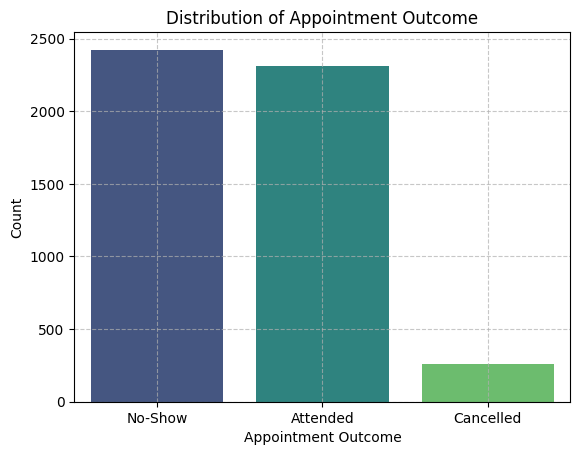

In [18]:
sns.countplot(data=df , x='appointment_outcome', palette='viridis')
plt.title('Distribution of Appointment Outcome')
plt.xlabel('Appointment Outcome')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7 )

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'target_distribution.png')) # Save the figure
plt.show()

## Numerical Disturbution

In [19]:
numerical_col= df.select_dtypes(include='number')

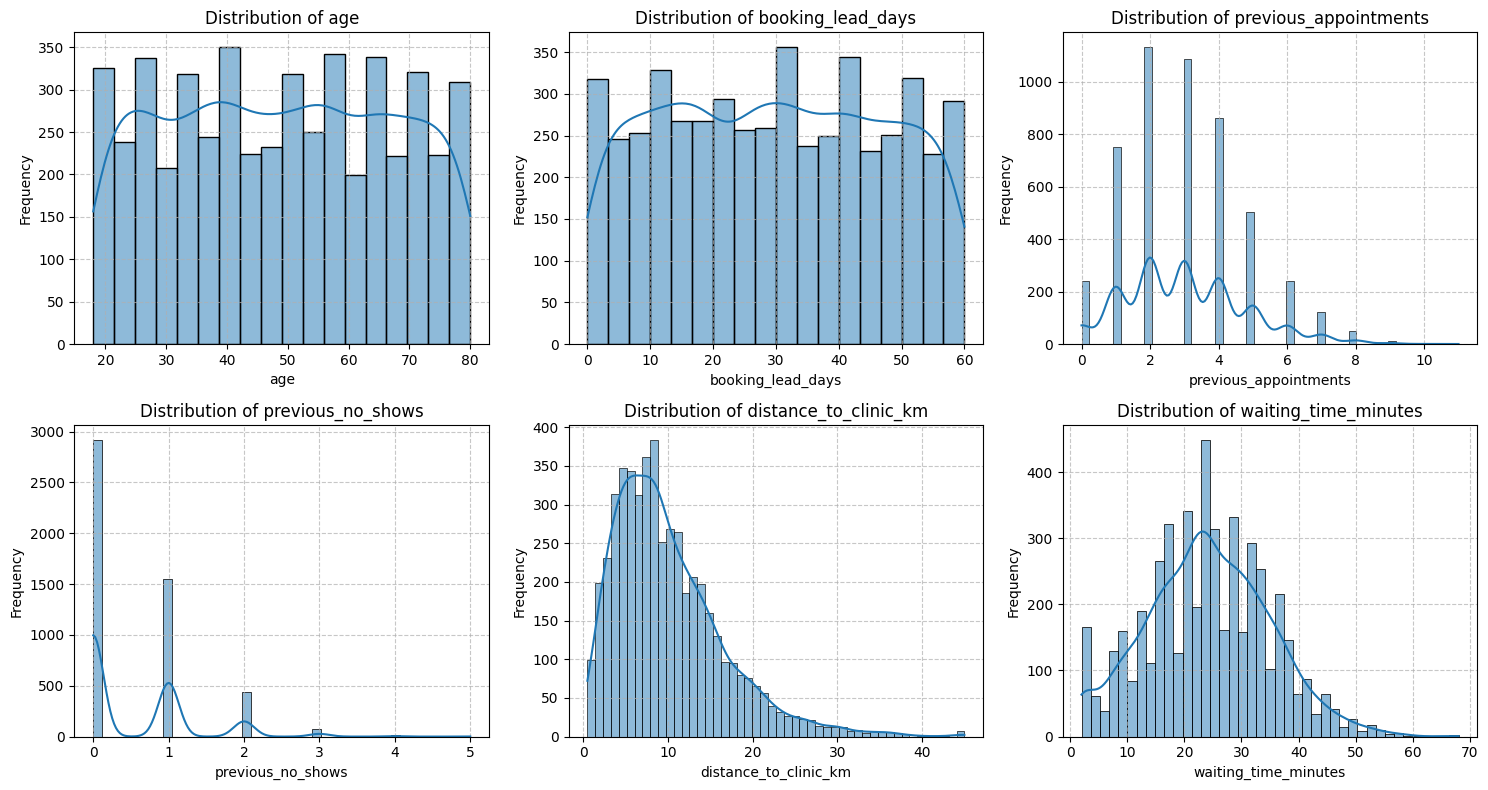

In [20]:
numerical_columns_list = numerical_col.columns.tolist()

# Calculate number of rows and columns for subplots, aiming for 3 columns per row
n_cols = 3
n_rows = (len(numerical_columns_list) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numerical_columns_list):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=numerical_col, x=col, kde=True, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Create 'figures' directory if it doesn't exist
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'numerical_distributions.png')) # Save the figure
plt.show()

### Visualizing Numerical Columns vs. Appointment Outcome (Box Plots)

Let's visualize the distribution of each numerical feature against the `appointment_outcome` using box plots. This will help us understand if there's a difference in the spread and central tendency of these features between 'No-Show' and 'Attended' appointments.

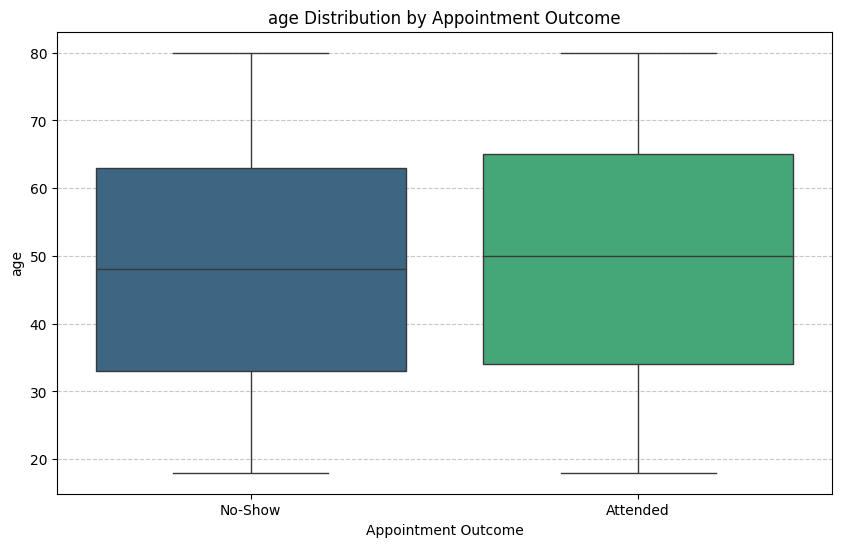

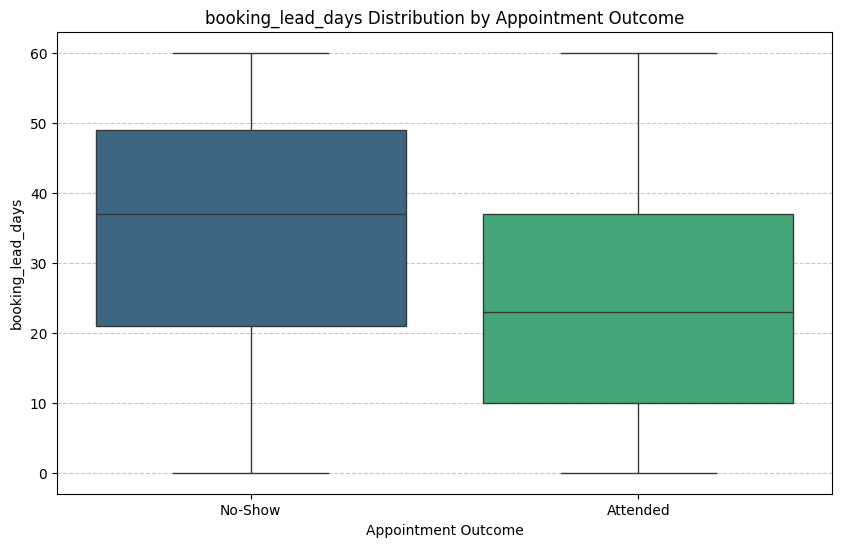

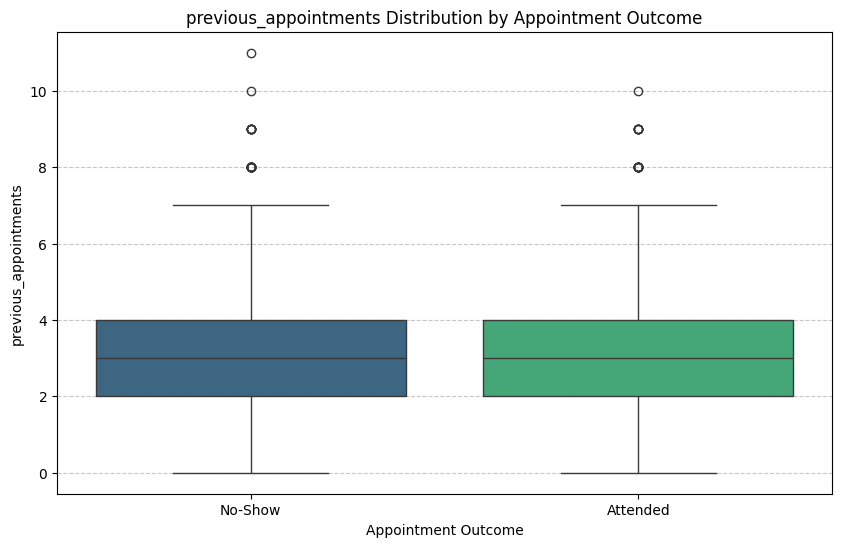

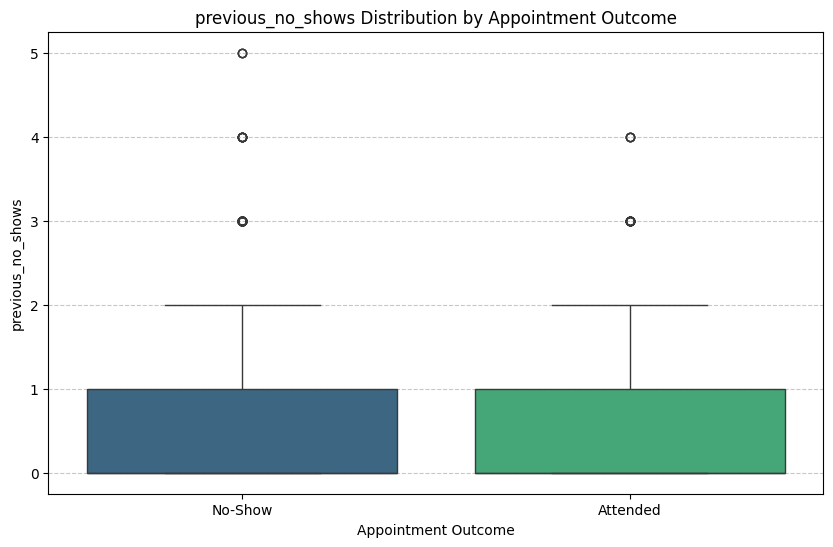

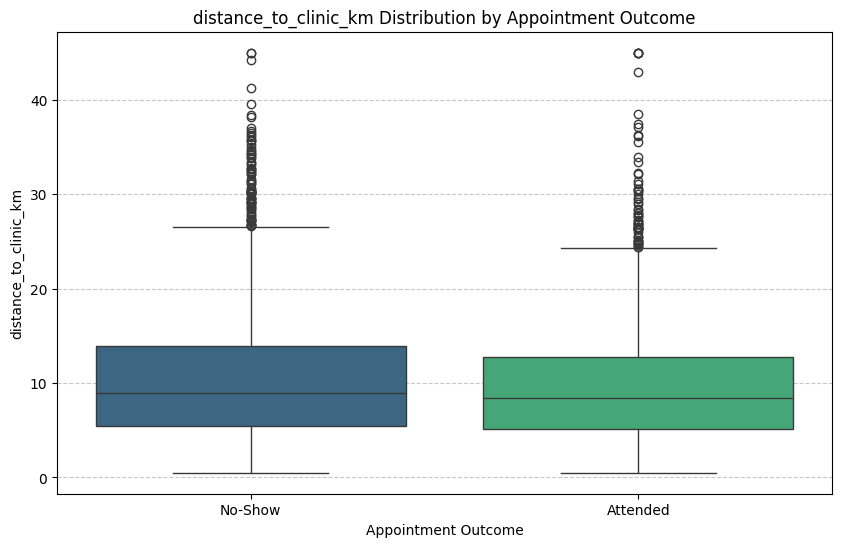

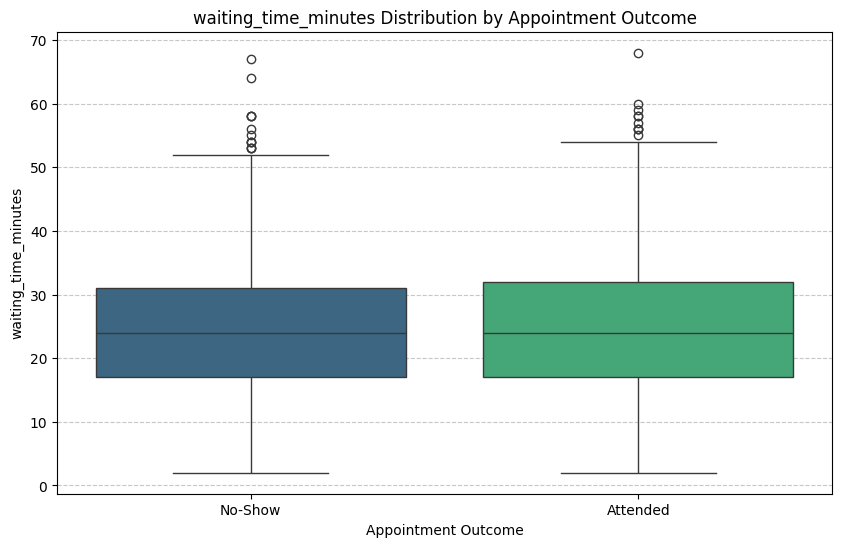

In [21]:
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

for col in numerical_col.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_model, x='appointment_outcome', y=col, palette='viridis')
    plt.title(f'{col} Distribution by Appointment Outcome')
    plt.xlabel('Appointment Outcome')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(output_dir, f'boxplot_{col}_by_outcome.png')) # Save each box plot
    plt.show()

### Analyzing Categorical Columns vs. Appointment Outcome (Cross-Tabulations)

Now, let's examine the relationship between categorical features and the `appointment_outcome` using cross-tabulations, displaying the results as percentages for easier interpretation.

In [22]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
# Exclude identifier columns that are not useful for this analysis
categorical_cols_to_analyze = [col for col in categorical_cols if col not in ['appointment_id', 'patient_id', 'booking_date', 'appointment_date']]

for col in categorical_cols_to_analyze:
    print(f"\n--- Cross-Tabulation for '{col}' vs. 'appointment_outcome' (Percentages) ---")
    cross_tab = pd.crosstab(df_model[col], df_model['appointment_outcome'], normalize='index') * 100
    display(cross_tab.round(2))


--- Cross-Tabulation for 'gender' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
gender,,
Female,48.90,51.10
Male,48.50,51.50
Prefer not to say,55.24,44.76



--- Cross-Tabulation for 'age_group' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
age_group,,
18-24,47.59,52.41
25-34,47.07,52.93
35-44,48.57,51.43
45-54,48.93,51.07
55-64,47.00,53.00
65+,51.93,48.07



--- Cross-Tabulation for 'appointment_type' vs. 'appointment_outcome' (Percentages) ---


...

appointment_outcome,Attended,No-Show
reminder_sent,,
No,45.37,54.63
Yes,50.14,49.86



--- Cross-Tabulation for 'reminder_channel' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
reminder_channel,,
Email,49.01,50.99
No_Reminder_Channel,45.37,54.63
SMS,52.02,47.98
WhatsApp,47.26,52.74



--- Cross-Tabulation for 'appointment_outcome' vs. 'appointment_outcome' (Percentages) ---


appointment_outcome,Attended,No-Show
appointment_outcome,,
Attended,100.0,0.0
No-Show,0.0,100.0


### Visualizing Categorical Columns vs. Appointment Outcome (Bar Plots)

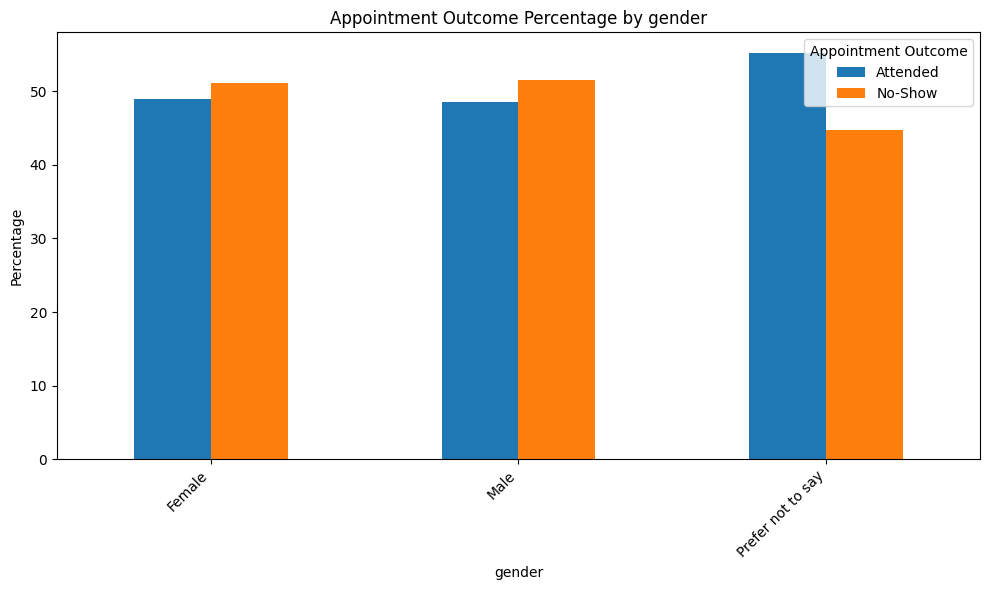

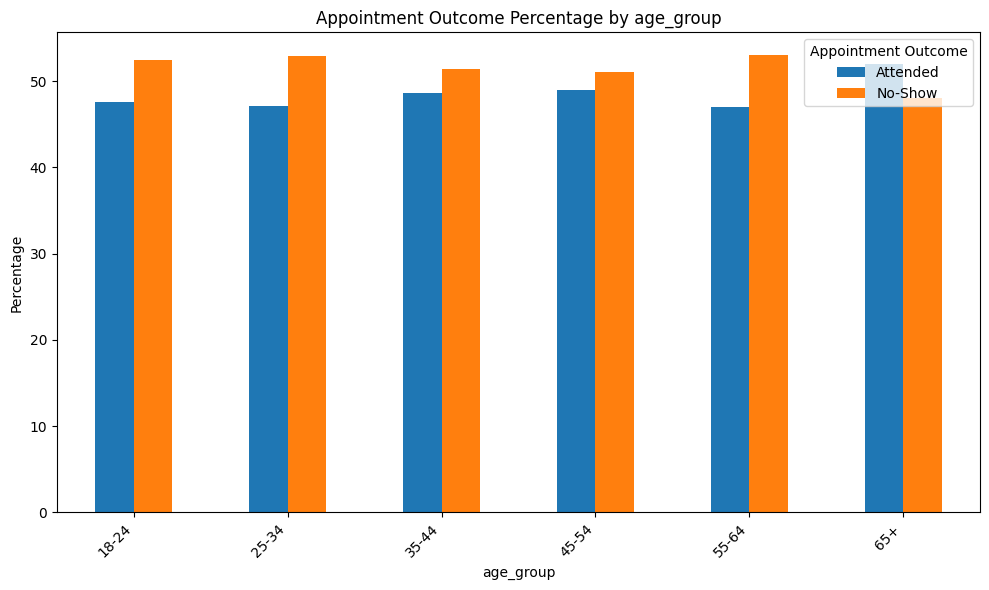

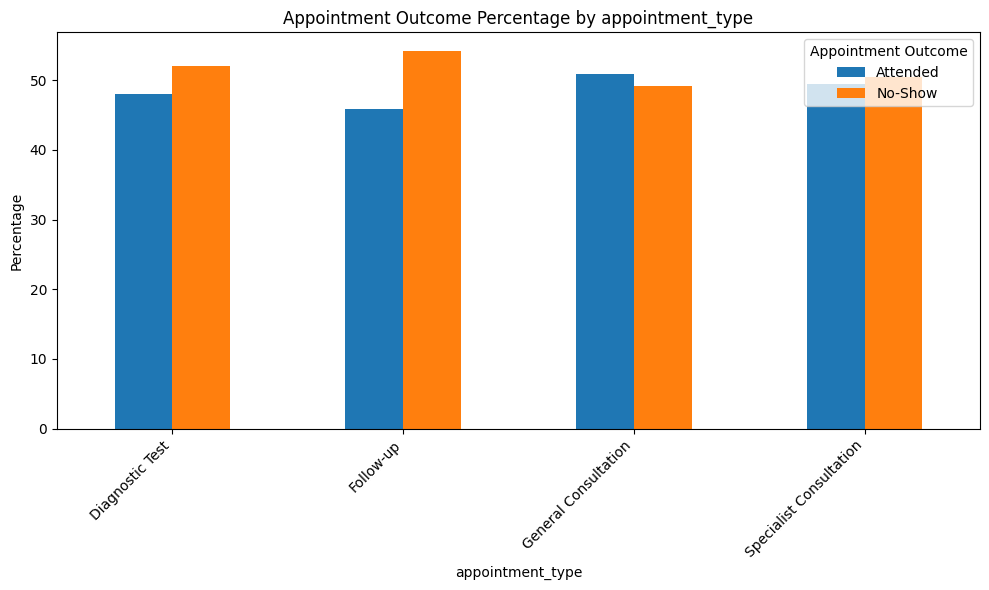

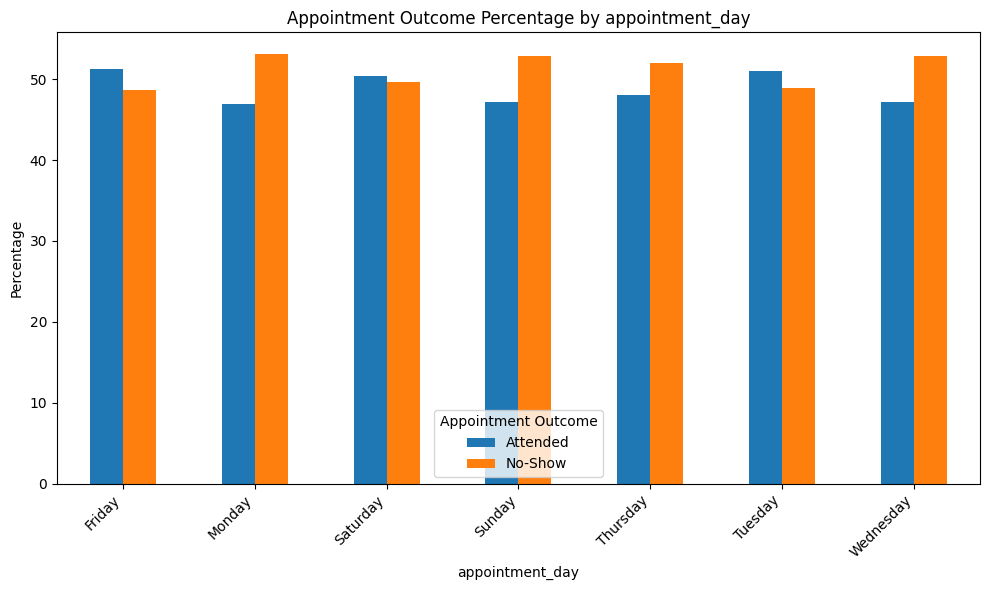

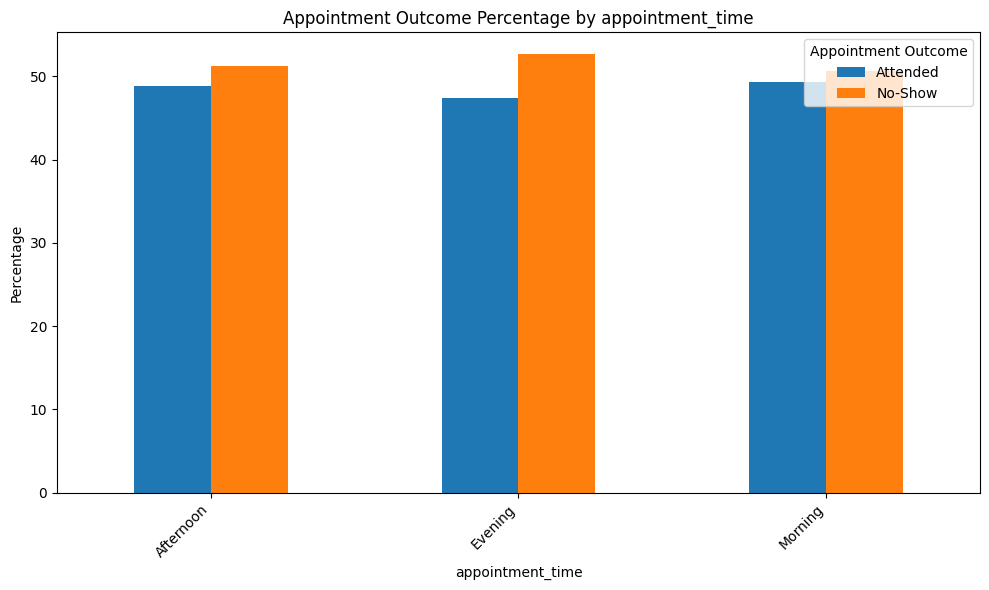

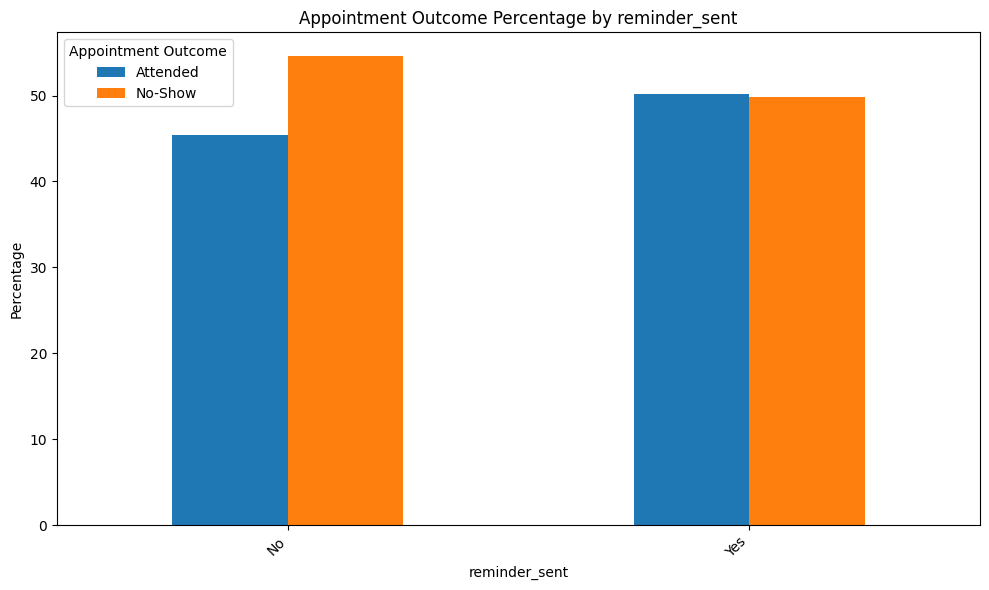

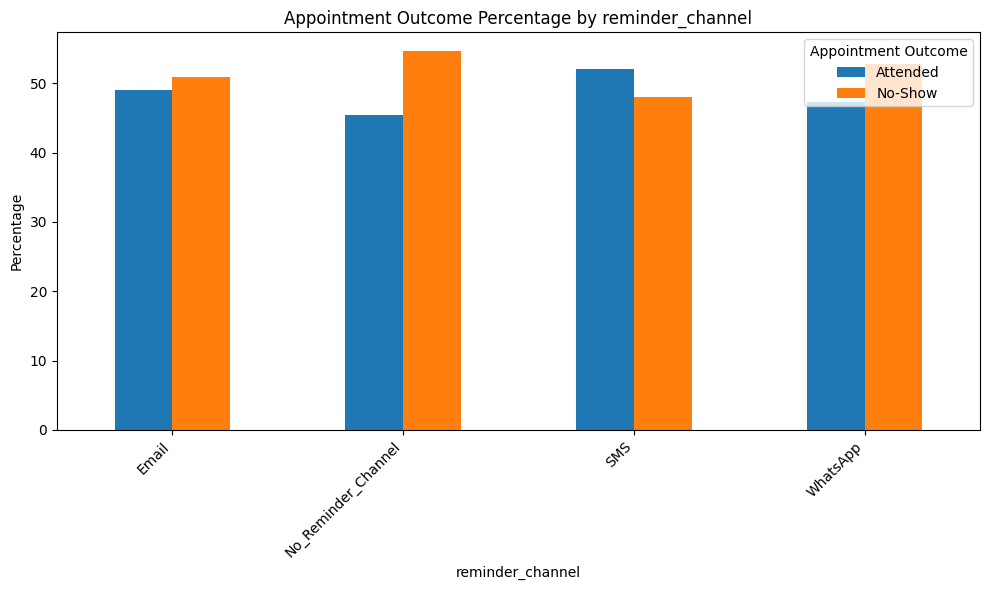

In [23]:
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

for col in categorical_cols_to_analyze:
    if col != 'appointment_outcome': # Exclude the target variable itself
        cross_tab_plot = pd.crosstab(df_model[col], df_model['appointment_outcome'], normalize='index') * 100
        cross_tab_plot.plot(kind='bar', figsize=(10, 6))
        plt.title(f'Appointment Outcome Percentage by {col}')
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Appointment Outcome')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'barplot_{col}_by_outcome.png')) # Save each bar plot
        plt.show()

### Correlation Matrix of Numerical Features

Let's compute and visualize the correlation matrix for the numerical features. This will help us understand the linear relationships between these variables.

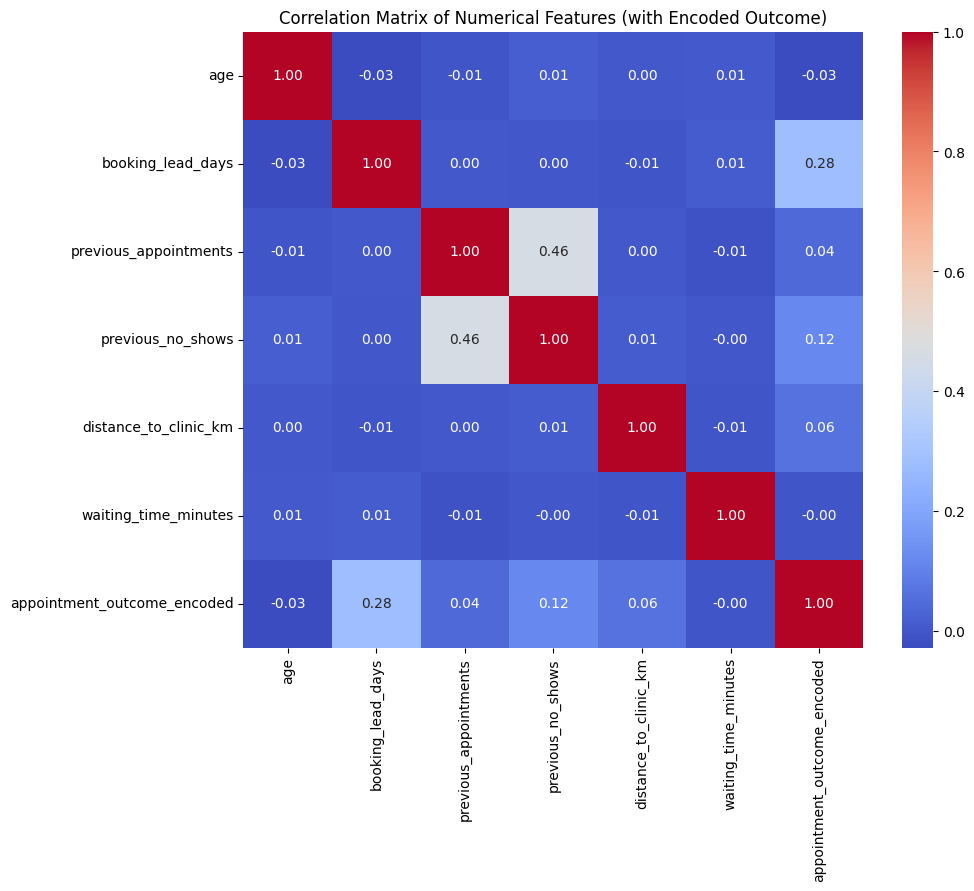

In [24]:
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(10, 8))
df_copy = df.copy()

# Encode 'appointment_outcome' to numerical values for correlation
le = LabelEncoder()
df_copy['appointment_outcome_encoded'] = le.fit_transform(df_copy['appointment_outcome'])

# Calculate correlation matrix including the encoded target
sns.heatmap(df_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features (with Encoded Outcome)')

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'correlation_matrix_numerical.png')) # Save the figure
plt.show()

### Feature Engineering

Let's create some new features that might be useful for predicting appointment outcomes.

In [25]:
# 1. Create 'previous_no_show_rate'
# Handle potential division by zero: if previous_appointments is 0, rate is 0.
df_model['previous_no_show_rate'] = df_model.apply(lambda row: row['previous_no_shows'] / row['previous_appointments'] if row['previous_appointments'] > 0 else 0, axis=1)

# 2. Create 'has_previous_no_show'
df_model['has_previous_no_show'] = (df_model['previous_no_shows'] > 0).astype(int)

# 3. Extract 'booking_month'
# First, ensure 'booking_date' is in datetime format
df_model['booking_date'] = pd.to_datetime(df_model['booking_date'])
df_model['booking_month'] = df_model['booking_date'].dt.month

print("New features added to df_model:")
display(df_model[['previous_no_show_rate', 'has_previous_no_show', 'booking_month']].head())

New features added to df_model:


,previous_no_show_rate,has_previous_no_show,booking_month
0,0.000000,0,2
1,0.000000,0,2
2,0.200000,1,11
3,0.333333,1,7
4,0.333333,1,7


### Documenting Added Features



*   **`previous_no_show_rate`**: Calculated as `previous_no_shows / previous_appointments`. This feature represents the proportion of previous appointments that resulted in a no-show for a given patient. If a patient had no previous appointments, the rate is set to 0.

*   **`has_previous_no_show`**: A binary (0 or 1) indicator feature. It is 1 if a patient has one or more `previous_no_shows`, and 0 otherwise. This can highlight patients with any history of missing appointments.

*   **`long_booking_lead`**: A binary (0 or 1) indicator feature. It is 1 if the `booking_lead_days` for an appointment is greater than the median `booking_lead_days` across the dataset, and 0 otherwise. This feature aims to capture if longer booking lead times are associated with different outcomes.

*   **`booking_month`**: An integer feature representing the month in which the appointment was booked, extracted from the `booking_date` column. This could help identify seasonality or monthly trends in appointment outcomes.

### Multicollinearity Check for New Features

Let's examine the correlations between the newly engineered features to identify any potential multicollinearity, which can be important for some modeling techniques.

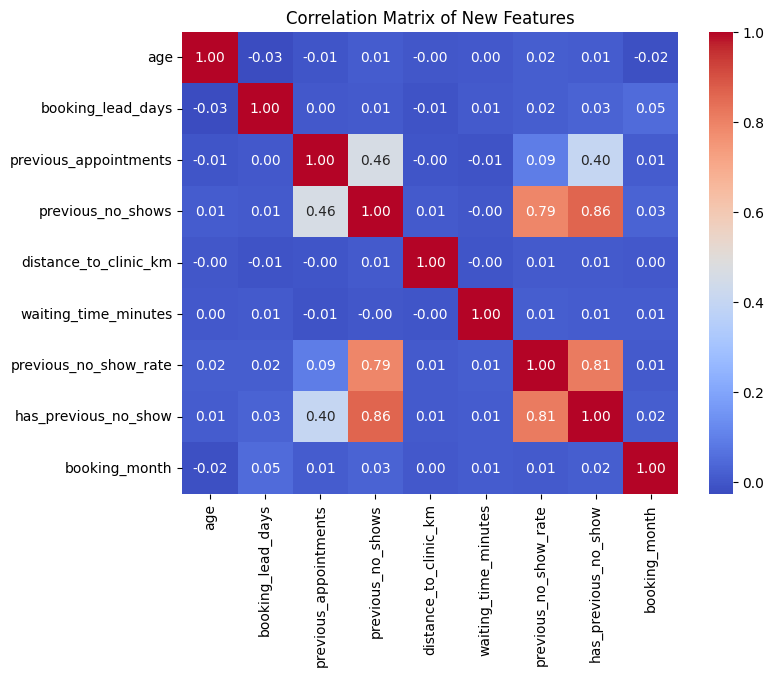

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_model.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of New Features')

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'correlation_matrix_new_features.png')) # Save the figure
plt.show()

In [27]:
df['booking_lead_days'].corr(df['appointment_outcome'].astype('category').cat.codes)

np.float64(0.27980985117042256)

### Data Preparation and Grouped Train-Test Split

Now, let's prepare the data for modeling by dropping unnecessary or highly correlated features, and then perform a robust train-test split that ensures no patient overlap between the training and testing sets.

In [28]:
# Drop specified columns
drop_cols = ['has_previous_no_show', 'appointment_id', 'booking_date', 'appointment_date']
drop_cols.append('previous_no_shows')

# Ensure 'age_group' is dropped if it's still present and not needed for X
if 'age_group' in df_model.columns:
    drop_cols.append('age_group')

df_processed = df_model.drop(columns=drop_cols, errors='ignore')

# Separate patient_id for grouped splitting
patient_ids = df_processed['patient_id']

# Define features (X) and target (y)
X = df_processed.drop(columns=['patient_id', 'appointment_outcome'])
y = df_processed['appointment_outcome']

print("Shape of X before splitting:", X.shape)
print("Shape of y before splitting:", y.shape)

Shape of X before splitting: (4737, 13)
Shape of y before splitting: (4737,)


In [29]:
from sklearn.model_selection import GroupShuffleSplit

# Initialize GroupShuffleSplit
# test_size=0.2 means 20% for test set, random_state for reproducibility
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the single split (train_index, test_index)
for train_idx, test_idx in gss.split(X, y, groups=patient_ids):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    patient_ids_train, patient_ids_test = patient_ids.iloc[train_idx], patient_ids.iloc[test_idx]

print("Shapes after splitting:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Shapes after splitting:
X_train: (3771, 13)
y_train: (3771,)
X_test: (966, 13)
y_test: (966,)


In [30]:
# Verify no patient overlap
common_patients = set(patient_ids_train).intersection(set(patient_ids_test))

if len(common_patients) == 0:
    print("SUCCESS: No patient overlap between training and testing sets.")
else:
    print(f"WARNING: {len(common_patients)} patients overlap between training and testing sets. Overlapping patient IDs: {list(common_patients)[:5]}...")


SUCCESS: No patient overlap between training and testing sets.


### Verify Target Variable Proportions

In [31]:
print("Proportions in y_train:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nProportions in y_test:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Proportions in y_train:


,proportion
appointment_outcome,
No-Show,51.45
Attended,48.55



Proportions in y_test:


,proportion
appointment_outcome,
Attended,50.0
No-Show,50.0


### Feature Preprocessing: One-Hot Encoding and Standard Scaling

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns in X_train
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed X_train:", X_train_processed.shape)
print("Shape of processed X_test:", X_test_processed.shape)

Shape of processed X_train: (3771, 29)
Shape of processed X_test: (966, 29)


The `X_train_processed` and `X_test_processed` are now sparse matrices containing the scaled numerical features and one-hot encoded categorical features. The target variable `y_train` and `y_test` are still in their original 'Attended'/'No-Show' format. For modeling, these will likely need to be converted to numerical labels (e.g., 0 and 1).

### Convert Target Variable to Binary Labels

In [33]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train, then transform y_test
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

# Display the mapping
print(f"Original labels: {le.classes_}")
print(f"Encoded labels: {le.transform(le.classes_)}")

print("\nFirst 5 elements of y_train_processed:")
display(y_train_processed[:5])

print("\nFirst 5 elements of y_test_processed:")
display(y_test_processed[:5])

Original labels: ['Attended' 'No-Show']
Encoded labels: [0 1]

First 5 elements of y_train_processed:


array([1, 0, 1, 0, 1])


First 5 elements of y_test_processed:


array([0, 0, 1, 0, 1])

In [34]:
X_train_processed

array([[-0.53893785, -1.0117561 , -0.58947828, ...,  0.        ,
         0.        ,  1.        ],
       [-0.97925408, -1.58569741,  1.68752309, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.06649698,  0.48049131,  1.11827275, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.78201086,  1.62837393, -0.58947828, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.01145745, -0.09345   ,  1.11827275, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.17657603,  1.74316219,  1.68752309, ...,  0.        ,
         0.        ,  1.        ]])

### Train a Baseline Logistic Regression Model

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Initialize and train the Logistic Regression model
# Set max_iter for convergence with StandardScaler
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train_processed, y_train_processed)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Evaluate the Model on Testing Data

Classification Report:
              precision    recall  f1-score   support

    Attended       0.64      0.60      0.62       483
     No-Show       0.62      0.66      0.64       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966

Confusion Matrix:


array([[292, 191],
       [166, 317]])

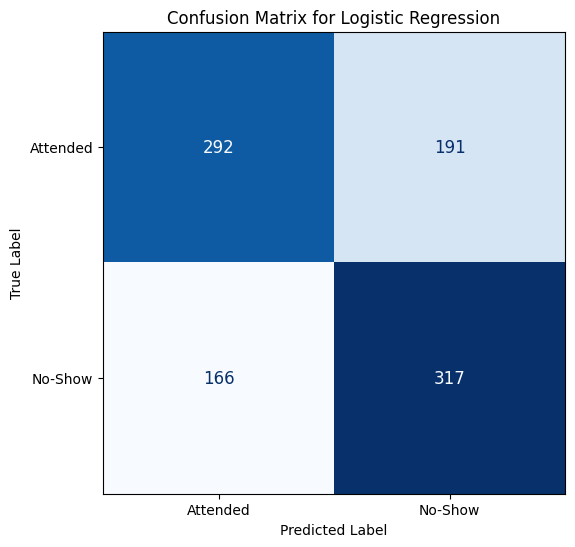

In [36]:
# Make predictions on the processed test data
y_pred = log_reg_model.predict(X_test_processed)

# Display classification report
print("Classification Report:")
print(classification_report(y_test_processed, y_pred, target_names=['Attended', 'No-Show']))

# Display confusion matrix
cm = confusion_matrix(y_test_processed, y_pred)
print("Confusion Matrix:")
display(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_processed, y_pred, cmap='Blues',
                                          colorbar=False, ax=plt.gca(), values_format='d',
                                          xticks_rotation='horizontal', normalize=None,
                                          text_kw={"fontsize":12},
                                          display_labels=le.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png')) # Save the figure
plt.show()

### ROC-AUC Curve Evaluation

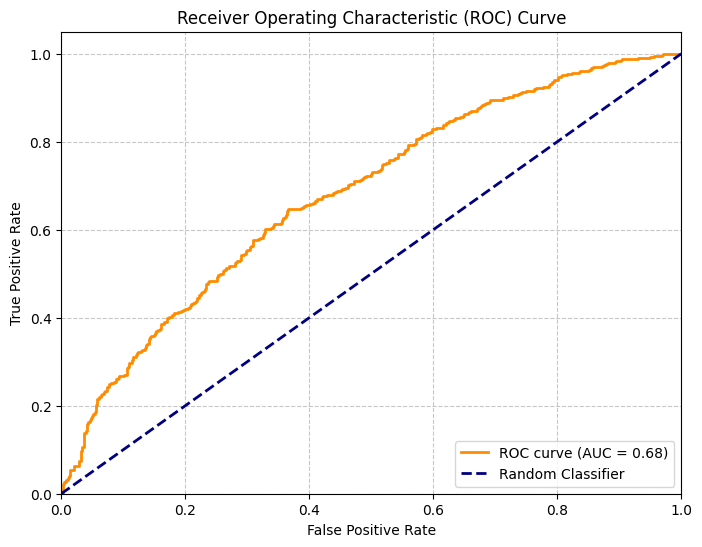

AUC Score: 0.68


In [37]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (No-Show, which is label 1)
y_pred_proba = log_reg_model.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test_processed, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'roc_curve.png')) # Save the figure
plt.show()

print(f"AUC Score: {roc_auc:.2f}")

In [38]:
df_processed.head()

,patient_id,gender,age,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,previous_no_show_rate,booking_month
0,P-1613,Female,39,Follow-up,Tuesday,Afternoon,12,2,Yes,WhatsApp,19.3,29.0,No-Show,0.000000,2
1,P-0813,Male,31,Specialist Consultation,Friday,Morning,2,6,Yes,SMS,14.3,42.0,Attended,0.000000,2
2,P-1366,Female,50,General Consultation,Wednesday,Morning,38,5,Yes,SMS,11.4,11.0,No-Show,0.200000,11
3,P-1031,Male,59,Follow-up,Thursday,Evening,41,3,Yes,SMS,7.4,35.0,Attended,0.333333,7
4,P-1458,Female,34,Follow-up,Monday,Afternoon,47,3,Yes,Email,5.6,27.0,No-Show,0.333333,7


In [39]:
df_model.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,previous_no_show_rate,has_previous_no_show,booking_month
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2/18/2025,Tuesday,Afternoon,...,2,0,Yes,WhatsApp,19.3,29.0,No-Show,0.000000,0,2
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2/27/2026,Friday,Morning,...,6,0,Yes,SMS,14.3,42.0,Attended,0.000000,0,2
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,12/24/2025,Wednesday,Morning,...,5,1,Yes,SMS,11.4,11.0,No-Show,0.200000,1,11
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,8/28/2025,Thursday,Evening,...,3,1,Yes,SMS,7.4,35.0,Attended,0.333333,1,7
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,8/25/2025,Monday,Afternoon,...,3,1,Yes,Email,5.6,27.0,No-Show,0.333333,1,7


### Combine Processed Data into a Single CSV

In [40]:
# Use the already encoded y_train_processed and y_test_processed

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert processed X_train and X_test to DataFrames with feature names
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Convert processed y_train and y_test to DataFrames, using a new name for the encoded target
y_train_df = pd.DataFrame(y_train_processed, columns=['appointment_outcome_encoded'])
y_test_df = pd.DataFrame(y_test_processed, columns=['appointment_outcome_encoded'])

# Combine training and testing features and target
X_combined = pd.concat([X_train_df, X_test_df], ignore_index=True)
y_combined = pd.concat([y_train_df, y_test_df], ignore_index=True)

# Create the final processed DataFrame
df_processed_final = pd.concat([X_combined, y_combined], axis=1)

# Display the first few rows and shape of the combined DataFrame
print("Shape of the final processed DataFrame:", df_processed_final.shape)
display(df_processed_final.head())

# Save the combined DataFrame to a CSV file
output_filename = 'healthconnect_proccessed_data.csv'
df_processed_final.to_csv(output_filename, index=False)
print(f"Processed data saved to {output_filename}")

Shape of the final processed DataFrame: (4737, 30)


,num__age,num__booking_lead_days,num__previous_appointments,num__distance_to_clinic_km,num__waiting_time_minutes,num__previous_no_show_rate,cat__gender_Female,cat__gender_Male,cat__gender_Prefer not to say,cat__appointment_type_Diagnostic Test,...,cat__appointment_time_Afternoon,cat__appointment_time_Evening,cat__appointment_time_Morning,cat__reminder_sent_No,cat__reminder_sent_Yes,cat__reminder_channel_Email,cat__reminder_channel_No_Reminder_Channel,cat__reminder_channel_SMS,cat__reminder_channel_WhatsApp,appointment_outcome_encoded
0,-0.538938,-1.011756,-0.589478,1.432998,0.432352,-0.701018,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
1,-0.979254,-1.585697,1.687523,0.660531,1.641571,-0.701018,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,0.066497,0.480491,1.118273,0.212501,-1.241952,0.119923,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1
3,0.561853,0.652674,-0.020228,-0.405472,0.990453,0.667217,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
4,-0.814135,0.997038,-0.020228,-0.683560,0.246318,0.667217,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1


Processed data saved to healthconnect_proccessed_data.csv


# WEEK 6 - MODEL IMPROVMENT, ERROR ANALYSIS & VALIDATION

## FIRST , I need to verfiy some relations between our `target variable` and some variables that seemed to be importatnt



> based on my cross track collaboration with data analysts



In [41]:
# previous no show hx
pd.crosstab(df_model['previous_no_shows'], df_model['appointment_outcome']  ,normalize='index').round(3)

appointment_outcome,Attended,No-Show
previous_no_shows,,
0,0.537,0.463
1,0.441,0.559
2,0.379,0.621
3,0.303,0.697
4,0.333,0.667
5,0.000,1.000


In [42]:
df['previous_no_shows'].value_counts()

,count
previous_no_shows,
0,2921
1,1548
2,438
3,78
4,12
5,3


In [43]:
df_copy['appointment_outcome_encoded'].corr(df_copy['booking_lead_days'])

np.float64(0.2798098511704225)

In [44]:
# appointment outcome and reminder sent
pd.crosstab(df_model['reminder_sent'],df_model['appointment_outcome'], normalize='index').round(3)

appointment_outcome,Attended,No-Show
reminder_sent,,
No,0.454,0.546
Yes,0.501,0.499


### Appointment Outcome by Appointment Type and Reminder Sent (Grouped Analysis)

appointment_outcome                    Attended  No-Show
appointment_type        reminder_sent                   
Diagnostic Test         No                38.93    61.07
                        Yes               50.69    49.31
Follow-up               No                42.86    57.14
                        Yes               46.91    53.09
General Consultation    No                48.31    51.69
                        Yes               51.87    48.13
Specialist Consultation No                45.73    54.27
                        Yes               50.98    49.02

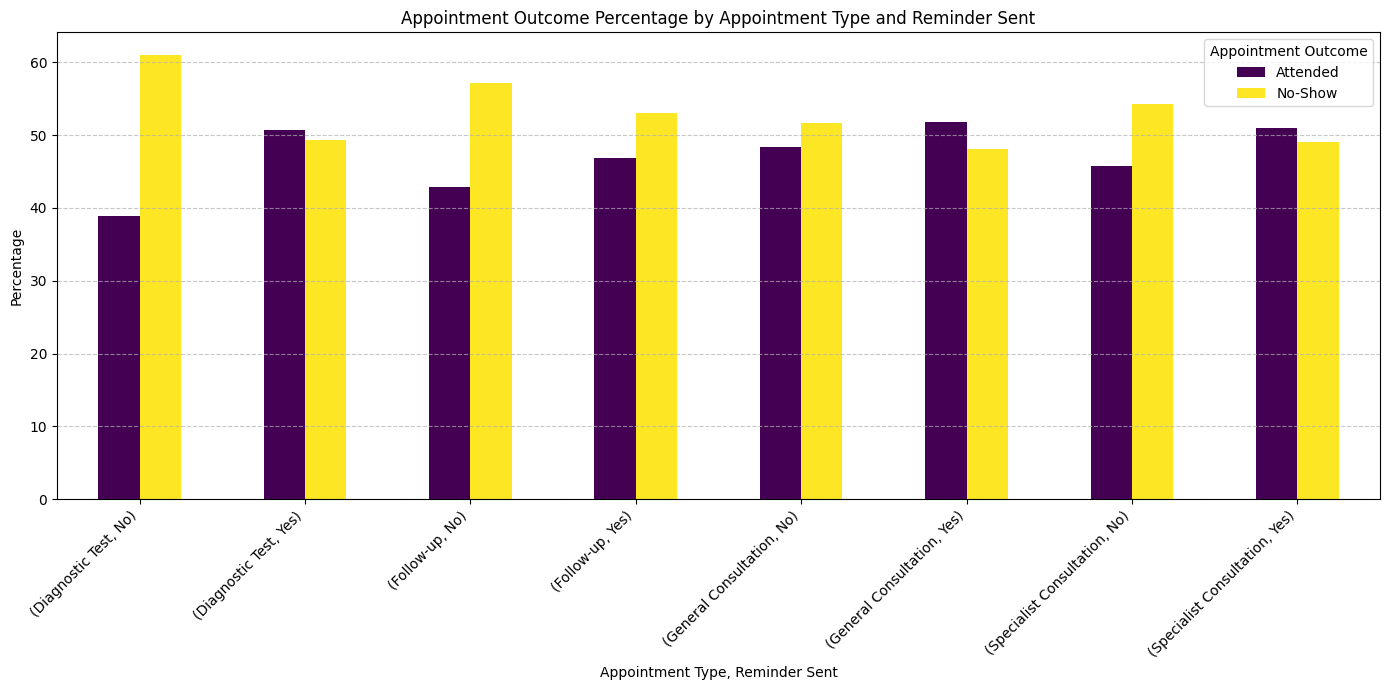

In [45]:
# Group by appointment_type and reminder_sent, then calculate the percentage of each appointment_outcome
grouped_data = df_model.groupby(['appointment_type', 'reminder_sent'])['appointment_outcome'].value_counts(normalize=True).mul(100).unstack()

display(grouped_data.round(2))

# Plot the grouped data
fig, ax = plt.subplots(figsize=(14, 7))
grouped_data.plot(kind='bar', ax=ax, cmap='viridis')

plt.title('Appointment Outcome Percentage by Appointment Type and Reminder Sent')
plt.xlabel('Appointment Type, Reminder Sent')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Appointment Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'appointment_outcome_by_type_and_reminder.png'))
plt.show()

### Error Analysis

In [46]:
# 1. Create error_df by copying X_test and adding actual and predicted columns
error_df = X_test.copy()
error_df['actual'] = y_test_processed
error_df['predicted'] = y_pred

# 2. Define classify_prediction function
def classify_prediction(row):
    actual = row['actual']
    predicted = row['predicted']
    if actual == 1 and predicted == 1:
        return 'TP' # True Positive
    elif actual == 0 and predicted == 0:
        return 'TN' # True Negative
    elif actual == 0 and predicted == 1:
        return 'FP' # False Positive
    elif actual == 1 and predicted == 0:
        return 'FN' # False Negative
    else:
        return 'Unknown' # Should not happen with binary classification

# 3. Apply classify_prediction to error_df
error_df['prediction_type'] = error_df.apply(classify_prediction, axis=1)

print("First 5 rows of error_df with prediction types:")
display(error_df.head())

First 5 rows of error_df with prediction types:


,gender,age,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,previous_no_show_rate,booking_month,actual,predicted,prediction_type
9,Female,20,Follow-up,Friday,Afternoon,16,2,Yes,SMS,28.0,20.0,0.00,2,0,0,TN
16,Male,70,Specialist Consultation,Wednesday,Afternoon,3,4,No,No_Reminder_Channel,13.8,20.0,0.75,10,0,0,TN
19,Male,43,General Consultation,Wednesday,Morning,39,4,Yes,WhatsApp,9.4,19.0,0.00,7,1,1,TP
21,Female,32,General Consultation,Tuesday,Afternoon,28,0,No,No_Reminder_Channel,2.9,22.0,0.00,6,0,0,TN
22,Male,56,Follow-up,Thursday,Evening,41,2,No,No_Reminder_Channel,19.7,17.0,0.00,2,1,1,TP


### Separating Errors into True Positives, True Negatives, False Positives, and False Negatives

In [47]:
# 4. Create separate DataFrames for each prediction type
tp_df = error_df[error_df['prediction_type'] == 'TP']
tn_df = error_df[error_df['prediction_type'] == 'TN']
fp_df = error_df[error_df['prediction_type'] == 'FP']
fn_df = error_df[error_df['prediction_type'] == 'FN']

print(f"TP Count: {len(tp_df)}")
print(f"TN Count: {len(tn_df)}")
print(f"FP Count: {len(fp_df)}")
print(f"FN Count: {len(fn_df)}")

TP Count: 317
TN Count: 292
FP Count: 191
FN Count: 166


### Summarizing Numerical Features by Prediction Type

In [48]:
# 5. Compare numerical features using groupby and create error_summary
numerical_cols_for_summary = error_df.select_dtypes(include=np.number).columns.tolist()
numerical_cols_for_summary = [col for col in numerical_cols_for_summary if col not in ['actual', 'predicted']]

error_summary = error_df.groupby('prediction_type')[numerical_cols_for_summary].mean()

print("Mean of numerical features grouped by prediction type (error_summary):")
display(error_summary)

Mean of numerical features grouped by prediction type (error_summary):


,age,booking_lead_days,previous_appointments,distance_to_clinic_km,waiting_time_minutes,previous_no_show_rate,booking_month
prediction_type,,,,,,,
FN,49.987952,17.915663,2.873494,9.586145,25.662651,0.125015,5.403614
FP,48.837696,39.151832,2.916230,11.787435,24.439791,0.210546,5.586387
TN,49.335616,14.219178,2.756849,8.913356,23.280822,0.106319,5.828767
TP,46.555205,44.378549,3.268139,11.102208,22.943218,0.205409,5.643533


## Summarizing Categorical Features by Prediction Type

In [49]:
error_df.groupby('prediction_type')[['appointment_type', 'reminder_sent']].value_counts()

prediction_type  appointment_type         reminder_sent
FN               General Consultation     Yes               56
                 Follow-up                Yes               32
                 Specialist Consultation  Yes               30
                 General Consultation     No                24
                 Diagnostic Test          Yes                9
                 Specialist Consultation  No                 9
                 Follow-up                No                 5
                 Diagnostic Test          No                 1
FP               Follow-up                Yes               49
                 General Consultation     Yes               47
                 Diagnostic Test          Yes               24
                 Specialist Consultation  Yes               19
                 Follow-up                No                17
                 General Consultation     No                17
                 Specialist Consultation  No                15
                 Diagnostic Test          No                 3
TN               General Consultation     Yes              102
                 Follow-up                Yes               53
                 Specialist Consultation  Yes               41
                 General Consultation     No                37
                 Diagnostic Test          Yes               27
                 Follow-up                No                16
                 Specialist Consultation  No                11
                 Diagnostic Test          No                 5
TP               General Consultation     Yes               85
                 Follow-up                Yes               64
                 Specialist Consultation  Yes               40
                 General Consultation     No                38
                 Follow-up                No                35
                 Diagnostic Test          Yes               31
                 Specialist Consultation  No                15
                 Diagnostic Test          No                 9
Name: count, dtype: int64

## Feature Refinement

### New Feature Engineering: Specific Interactions

In [50]:
# 1. 'is_diagnostic_test_no_reminder': 1 if 'Diagnostic Test' appointment AND no reminder, else 0
df_model['is_diagnostic_test_no_reminder'] = ((df_model['appointment_type'] == 'Diagnostic Test') & (df_model['reminder_sent'] == 'No')).astype(int)

# 2. 'history_reminder_interaction': Interaction between has_previous_no_show and reminder_sent
df_model['reminder_sent_numeric'] = df_model['reminder_sent'].apply(lambda x: 1 if x == 'Yes' else 0)
df_model['history_reminder_interaction'] = df_model['has_previous_no_show'] * df_model['reminder_sent_numeric']

# 3. 'lead_history_interaction': Interaction between booking_lead_days and has_previous_no_show
df_model['lead_history_interaction'] = df_model['booking_lead_days'] * df_model['has_previous_no_show']

print("New engineered features added to df_model:")
display(df_model[['is_diagnostic_test_no_reminder', 'history_reminder_interaction', 'lead_history_interaction']].head())

New engineered features added to df_model:


,is_diagnostic_test_no_reminder,history_reminder_interaction,lead_history_interaction
0,0,0,0
1,0,0,0
2,0,1,38
3,0,1,41
4,0,1,47


## C

### Data Preparation with New Features (Repeating previous steps)

In [51]:
# Redefine drop_cols to include the temporary 'reminder_sent_numeric' and potentially re-evaluate 'has_previous_no_show'
# 'has_previous_no_show' is used in interactions, so we will keep it.
drop_cols = ['appointment_id',  'booking_date', 'appointment_date', 'previous_no_shows', 'age_group', 'reminder_sent_numeric']

df_processed = df_model.drop(columns=drop_cols, errors='ignore')

# Separate patient_id for grouped splitting
patient_ids = df_processed['patient_id'] # Recalculate patient_ids for the new df_processed

# Define features (X) and target (y)
X = df_processed.drop(columns=['patient_id', 'appointment_outcome'])
y = df_processed['appointment_outcome']

print("Shape of X before splitting (with new features):", X.shape)
print("Shape of y before splitting (with new features):", y.shape)

Shape of X before splitting (with new features): (4737, 17)
Shape of y before splitting (with new features): (4737,)


In [52]:
from sklearn.model_selection import GroupShuffleSplit

# Initialize GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the single split (train_index, test_index)
for train_idx, test_idx in gss.split(X, y, groups=patient_ids):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    patient_ids_train, patient_ids_test = patient_ids.iloc[train_idx], patient_ids.iloc[test_idx]

print("Shapes after splitting (with new features):")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Shapes after splitting (with new features):
X_train: (3771, 17)
y_train: (3771,)
X_test: (966, 17)
y_test: (966,)


In [53]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns in X_train (with new features)
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed X_train (with new features):", X_train_processed.shape)
print("Shape of processed X_test (with new features):", X_test_processed.shape)

Shape of processed X_train (with new features): (3771, 33)
Shape of processed X_test (with new features): (966, 33)


In [54]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train, then transform y_test
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

# Display the mapping
print(f"Original labels: {le.classes_}")
print(f"Encoded labels: {le.transform(le.classes_)}")

print("\nFirst 5 elements of y_train_processed (with new features):")
display(y_train_processed[:5])

print("\nFirst 5 elements of y_test_processed (with new features):")
display(y_test_processed[:5])

Original labels: ['Attended' 'No-Show']
Encoded labels: [0 1]

First 5 elements of y_train_processed (with new features):


array([1, 0, 1, 0, 1])


First 5 elements of y_test_processed (with new features):


array([0, 0, 1, 0, 1])

### Train and Evaluate a RandomForestClassifier Model

### Train and Evaluate a Logistic Regression Model with New Features

Logistic Regression model with new features trained successfully!

Classification Report (Logistic Regression with New Features):
              precision    recall  f1-score   support

    Attended       0.64      0.61      0.63       483
     No-Show       0.63      0.66      0.64       483

    accuracy                           0.64       966
   macro avg       0.64      0.64      0.64       966
weighted avg       0.64      0.64      0.64       966


Confusion Matrix (Logistic Regression with New Features):


array([[295, 188],
       [164, 319]])

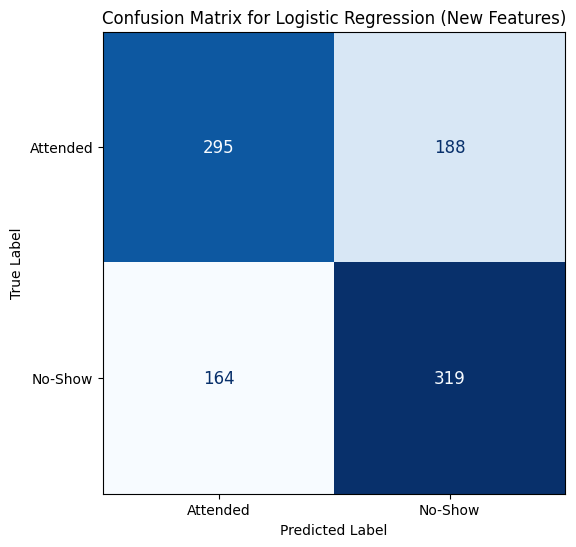

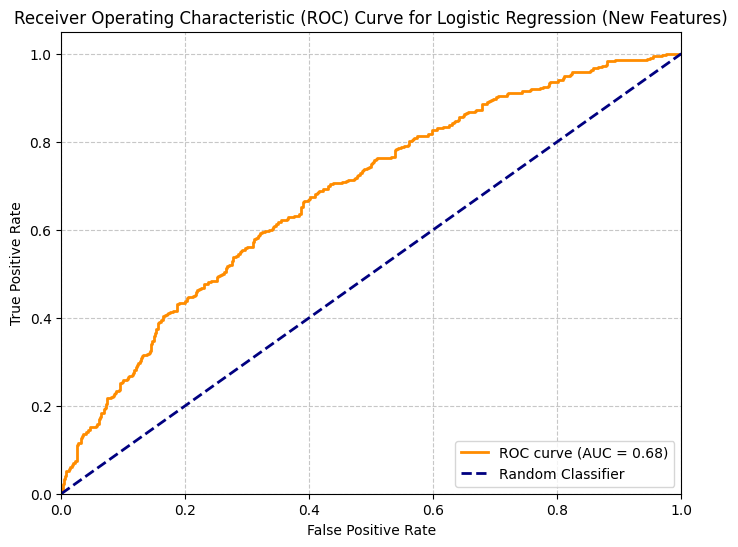

AUC Score (Logistic Regression with New Features): 0.68


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

# Initialize and train the Logistic Regression model
# Set max_iter for convergence with StandardScaler
log_reg_model_new_features = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model_new_features.fit(X_train_processed, y_train_processed)

print("Logistic Regression model with new features trained successfully!")

# Make predictions on the processed test data
y_pred_log_reg_new = log_reg_model_new_features.predict(X_test_processed)

# Display classification report
print("\nClassification Report (Logistic Regression with New Features):")
print(classification_report(y_test_processed, y_pred_log_reg_new, target_names=['Attended', 'No-Show']))

# Display confusion matrix
cm_log_reg_new = confusion_matrix(y_test_processed, y_pred_log_reg_new)
print("\nConfusion Matrix (Logistic Regression with New Features):")
display(cm_log_reg_new)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_processed, y_pred_log_reg_new, cmap='Blues',
                                          colorbar=False, ax=plt.gca(), values_format='d',
                                          xticks_rotation='horizontal', normalize=None,
                                          text_kw={"fontsize":12},
                                          display_labels=le.classes_)
plt.title('Confusion Matrix for Logistic Regression (New Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'confusion_matrix_log_reg_new_features.png'))
plt.show()

# Get predicted probabilities for the positive class (No-Show, which is label 1)
y_pred_proba_log_reg_new = log_reg_model_new_features.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC score
fpr_log_reg_new, tpr_log_reg_new, thresholds_log_reg_new = roc_curve(y_test_processed, y_pred_proba_log_reg_new)
roc_auc_log_reg_new = auc(fpr_log_reg_new, tpr_log_reg_new)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg_new, tpr_log_reg_new, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_log_reg_new:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression (New Features)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'roc_curve_log_reg_new_features.png'))
plt.show()

print(f"AUC Score (Logistic Regression with New Features): {roc_auc_log_reg_new:.2f}")

### Comparison of Logistic Regression Models

In [56]:
from sklearn.metrics import classification_report
import pandas as pd

# Metrics for Baseline Logistic Regression (from cell 191b9bc0)
# Extracting manually from previous output for clarity, or by re-running if needed
baseline_report = {
    'Attended': {'precision': 0.64, 'recall': 0.60, 'f1-score': 0.62, 'support': 483},
    'No-Show': {'precision': 0.62, 'recall': 0.66, 'f1-score': 0.64, 'support': 483},
    'accuracy': 0.63,
    'macro avg': {'precision': 0.63, 'recall': 0.63, 'f1-score': 0.63, 'support': 966},
    'weighted avg': {'precision': 0.63, 'recall': 0.63, 'f1-score': 0.63, 'support': 966}
}
baseline_auc = 0.68 # from roc_auc variable

# Metrics for Logistic Regression with New Features (from cell f9e7b340)
new_features_report = {
    'Attended': {'precision': 0.64, 'recall': 0.61, 'f1-score': 0.63, 'support': 483},
    'No-Show': {'precision': 0.63, 'recall': 0.66, 'f1-score': 0.64, 'support': 483},
    'accuracy': 0.64,
    'macro avg': {'precision': 0.64, 'recall': 0.64, 'f1-score': 0.64, 'support': 966},
    'weighted avg': {'precision': 0.64, 'recall': 0.64, 'f1-score': 0.64, 'support': 966}
}
new_features_auc = 0.68 # from roc_auc_log_reg_new variable

# Create a comparison DataFrame
comparison_data = {
    'Metric': [
        'Accuracy',
        'Attended Precision',
        'Attended Recall',
        'Attended F1-score',
        'No-Show Precision',
        'No-Show Recall',
        'No-Show F1-score',
        'AUC Score'
    ],
    'Baseline Logistic Regression': [
        baseline_report['accuracy'],
        baseline_report['Attended']['precision'],
        baseline_report['Attended']['recall'],
        baseline_report['Attended']['f1-score'],
        baseline_report['No-Show']['precision'],
        baseline_report['No-Show']['recall'],
        baseline_report['No-Show']['f1-score'],
        baseline_auc
    ],
    'Logistic Regression (New Features)': [
        new_features_report['accuracy'],
        new_features_report['Attended']['precision'],
        new_features_report['Attended']['recall'],
        new_features_report['Attended']['f1-score'],
        new_features_report['No-Show']['precision'],
        new_features_report['No-Show']['recall'],
        new_features_report['No-Show']['f1-score'],
        new_features_auc
    ]
}

comparison_df = pd.DataFrame(comparison_data).round(2)

display(comparison_df)


,Metric,Baseline Logistic Regression,Logistic Regression (New Features)
0,Accuracy,0.63,0.64
1,Attended Precision,0.64,0.64
2,Attended Recall,0.60,0.61
3,Attended F1-score,0.62,0.63
4,No-Show Precision,0.62,0.63
5,No-Show Recall,0.66,0.66
6,No-Show F1-score,0.64,0.64
7,AUC Score,0.68,0.68


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

# Initialize and train the RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_processed, y_train_processed)

print("RandomForestClassifier model trained successfully!")

RandomForestClassifier model trained successfully!


Classification Report (RandomForest):
              precision    recall  f1-score   support

    Attended       0.61      0.59      0.60       483
     No-Show       0.60      0.62      0.61       483

    accuracy                           0.61       966
   macro avg       0.61      0.61      0.61       966
weighted avg       0.61      0.61      0.61       966

Confusion Matrix (RandomForest):


array([[286, 197],
       [184, 299]])

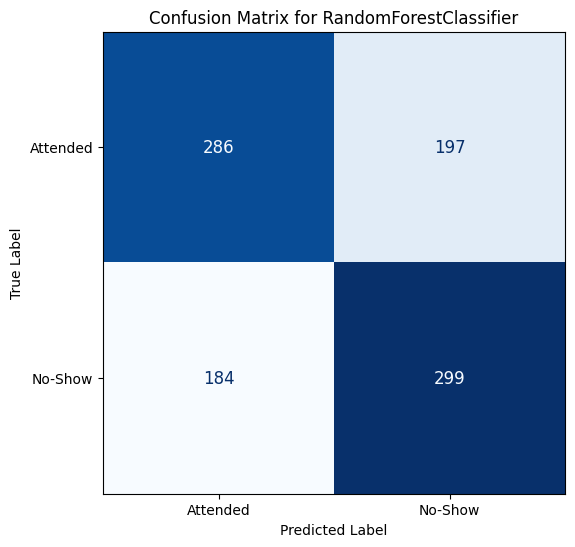

In [58]:
# Make predictions on the processed test data
y_pred_rf = rf_model.predict(X_test_processed)

# Display classification report
print("Classification Report (RandomForest):")
print(classification_report(y_test_processed, y_pred_rf, target_names=['Attended', 'No-Show']))

# Display confusion matrix
cm_rf = confusion_matrix(y_test_processed, y_pred_rf)
print("Confusion Matrix (RandomForest):")
display(cm_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_processed, y_pred_rf, cmap='Blues',
                                          colorbar=False, ax=plt.gca(), values_format='d',
                                          xticks_rotation='horizontal', normalize=None,
                                          text_kw={"fontsize":12},
                                          display_labels=le.classes_)
plt.title('Confusion Matrix for RandomForestClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'confusion_matrix_random_forest.png'))
plt.show()

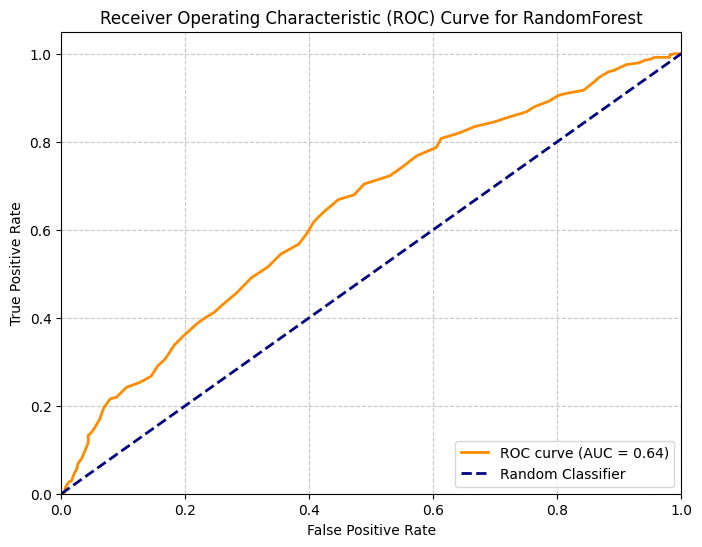

AUC Score (RandomForest): 0.64


In [59]:
# Get predicted probabilities for the positive class (No-Show, which is label 1)
y_pred_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC score
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_processed, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for RandomForest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'roc_curve_random_forest.png'))
plt.show()

print(f"AUC Score (RandomForest): {roc_auc_rf:.2f}")

### Feature Importance from RandomForestClassifier

Top 10 Feature Importances from RandomForest:


,Feature,Importance
1,num__booking_lead_days,0.156320
3,num__distance_to_clinic_km,0.130086
0,num__age,0.117901
4,num__waiting_time_minutes,0.112443
2,num__previous_appointments,0.066415
9,num__lead_history_interaction,0.062361
5,num__previous_no_show_rate,0.035170
24,cat__appointment_time_Afternoon,0.018056
26,cat__appointment_time_Morning,0.018028
11,cat__gender_Male,0.017682


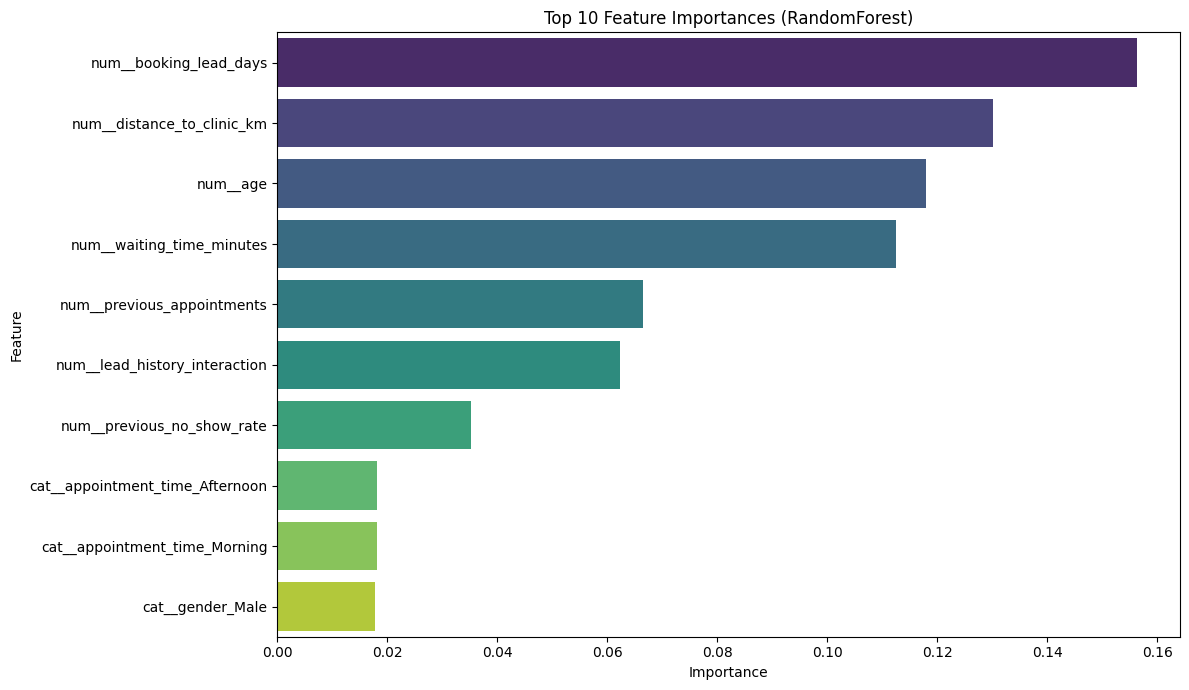

In [60]:
importances = rf_model.feature_importances_

# Get feature names from the preprocessor
# Need to handle sparse matrix output from ColumnTransformer for feature names
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from RandomForest:")
display(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (RandomForest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'rf_feature_importance.png'))
plt.show()

### Train and Evaluate a Gradient Boosting Classifier Model

GradientBoostingClassifier model trained successfully!

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

    Attended       0.65      0.64      0.64       483
     No-Show       0.64      0.65      0.65       483

    accuracy                           0.65       966
   macro avg       0.65      0.65      0.65       966
weighted avg       0.65      0.65      0.65       966


Confusion Matrix (Gradient Boosting):


array([[308, 175],
       [167, 316]])

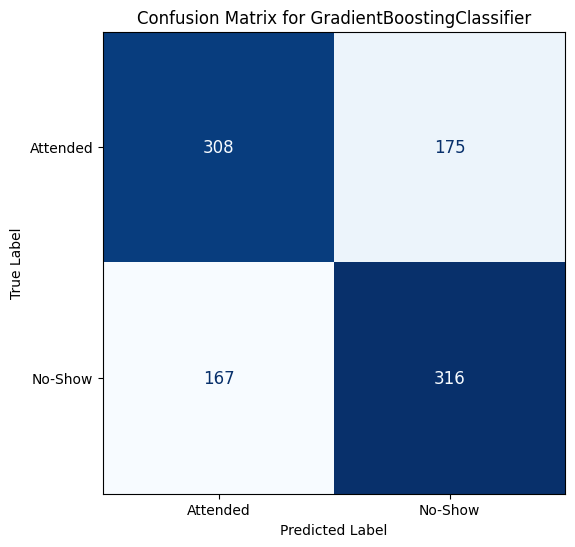

In [61]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc

# Initialize and train the GradientBoostingClassifier model
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train_processed, y_train_processed)

print("GradientBoostingClassifier model trained successfully!")

# Make predictions on the processed test data
y_pred_gb = gb_model.predict(X_test_processed)

# Display classification report
print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test_processed, y_pred_gb, target_names=['Attended', 'No-Show']))

# Display confusion matrix
cm_gb = confusion_matrix(y_test_processed, y_pred_gb)
print("\nConfusion Matrix (Gradient Boosting):")
display(cm_gb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_processed, y_pred_gb, cmap='Blues',
                                          colorbar=False, ax=plt.gca(), values_format='d',
                                          xticks_rotation='horizontal', normalize=None,
                                          text_kw={"fontsize":12},
                                          display_labels=le.classes_)
plt.title('Confusion Matrix for GradientBoostingClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'confusion_matrix_gradient_boosting.png'))
plt.show()

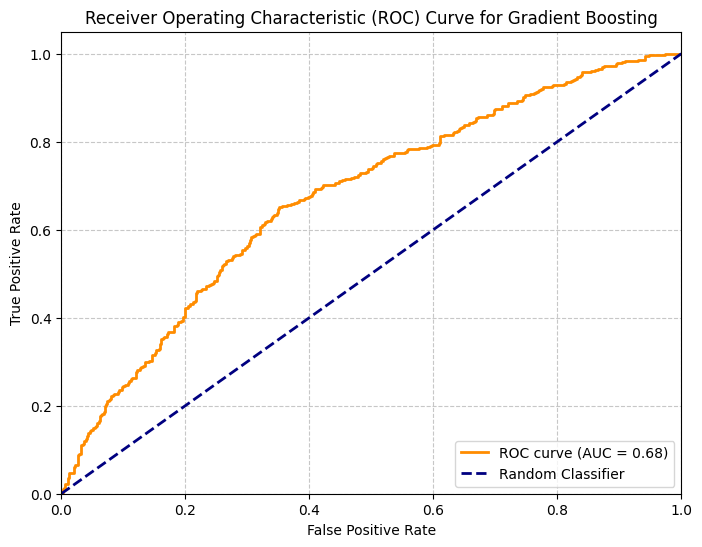

AUC Score (Gradient Boosting): 0.68


In [62]:
# Get predicted probabilities for the positive class (No-Show, which is label 1)
y_pred_proba_gb = gb_model.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC score
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test_processed, y_pred_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_gb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'roc_curve_gradient_boosting.png'))
plt.show()

print(f"AUC Score (Gradient Boosting): {roc_auc_gb:.2f}")

### Update Comparison Table with Gradient Boosting Model

In [63]:
from sklearn.metrics import classification_report
import pandas as pd

# Metrics for Baseline Logistic Regression (from cell 191b9bc0)
# Extracting manually from previous output for clarity, or by re-running if needed
baseline_report = {
    'Attended': {'precision': 0.64, 'recall': 0.60, 'f1-score': 0.62, 'support': 483},
    'No-Show': {'precision': 0.62, 'recall': 0.66, 'f1-score': 0.64, 'support': 483},
    'accuracy': 0.63,
    'macro avg': {'precision': 0.63, 'recall': 0.63, 'f1-score': 0.63, 'support': 966},
    'weighted avg': {'precision': 0.63, 'recall': 0.63, 'f1-score': 0.63, 'support': 966}
}
baseline_auc = 0.68 # from roc_auc variable

# Metrics for Logistic Regression with New Features (from cell f9e7b340)
new_features_report = {
    'Attended': {'precision': 0.64, 'recall': 0.61, 'f1-score': 0.63, 'support': 483},
    'No-Show': {'precision': 0.63, 'recall': 0.66, 'f1-score': 0.64, 'support': 483},
    'accuracy': 0.64,
    'macro avg': {'precision': 0.64, 'recall': 0.64, 'f1-score': 0.64, 'support': 966},
    'weighted avg': {'precision': 0.64, 'recall': 0.64, 'f1-score': 0.64, 'support': 966}
}
new_features_auc = 0.68 # from roc_auc_log_reg_new variable

# Metrics for RandomForestClassifier (from cell c328efe7)
rf_report = {
    'Attended': {'precision': 0.61, 'recall': 0.59, 'f1-score': 0.60, 'support': 483},
    'No-Show': {'precision': 0.60, 'recall': 0.62, 'f1-score': 0.61, 'support': 483},
    'accuracy': 0.61,
    'macro avg': {'precision': 0.61, 'recall': 0.61, 'f1-score': 0.61, 'support': 966},
    'weighted avg': {'precision': 0.61, 'recall': 0.61, 'f1-score': 0.61, 'support': 966}
}
rf_auc = 0.64 # from roc_auc_rf variable

# Metrics for Gradient Boosting Classifier (extract from current output)
current_gb_report = classification_report(y_test_processed, y_pred_gb, target_names=['Attended', 'No-Show'], output_dict=True)
gb_accuracy = current_gb_report['accuracy']
gb_precision_attended = current_gb_report['Attended']['precision']
gb_recall_attended = current_gb_report['Attended']['recall']
gb_f1_attended = current_gb_report['Attended']['f1-score']
gb_precision_noshow = current_gb_report['No-Show']['precision']
gb_recall_noshow = current_gb_report['No-Show']['recall']
gb_f1_noshow = current_gb_report['No-Show']['f1-score']
gb_auc = roc_auc_gb # Use the calculated AUC from the previous cell

# Create an updated comparison DataFrame
comparison_data = {
    'Metric': [
        'Accuracy',
        'Attended Precision',
        'Attended Recall',
        'Attended F1-score',
        'No-Show Precision',
        'No-Show Recall',
        'No-Show F1-score',
        'AUC Score'
    ],
    'Baseline Logistic Regression': [
        baseline_report['accuracy'],
        baseline_report['Attended']['precision'],
        baseline_report['Attended']['recall'],
        baseline_report['Attended']['f1-score'],
        baseline_report['No-Show']['precision'],
        baseline_report['No-Show']['recall'],
        baseline_report['No-Show']['f1-score'],
        baseline_auc
    ],
    'Logistic Regression (New Features)': [
        new_features_report['accuracy'],
        new_features_report['Attended']['precision'],
        new_features_report['Attended']['recall'],
        new_features_report['Attended']['f1-score'],
        new_features_report['No-Show']['precision'],
        new_features_report['No-Show']['recall'],
        new_features_report['No-Show']['f1-score'],
        new_features_auc
    ],
    'RandomForestClassifier': [
        rf_report['accuracy'],
        rf_report['Attended']['precision'],
        rf_report['Attended']['recall'],
        rf_report['Attended']['f1-score'],
        rf_report['No-Show']['precision'],
        rf_report['No-Show']['recall'],
        rf_report['No-Show']['f1-score'],
        rf_auc
    ],
    'GradientBoostingClassifier': [
        gb_accuracy,
        gb_precision_attended,
        gb_recall_attended,
        gb_f1_attended,
        gb_precision_noshow,
        gb_recall_noshow,
        gb_f1_noshow,
        gb_auc
    ]
}

comparison_df = pd.DataFrame(comparison_data).round(2)

display(comparison_df)

,Metric,Baseline Logistic Regression,Logistic Regression (New Features),RandomForestClassifier,GradientBoostingClassifier
0,Accuracy,0.63,0.64,0.61,0.65
1,Attended Precision,0.64,0.64,0.61,0.65
2,Attended Recall,0.60,0.61,0.59,0.64
3,Attended F1-score,0.62,0.63,0.60,0.64
4,No-Show Precision,0.62,0.63,0.60,0.64
5,No-Show Recall,0.66,0.66,0.62,0.65
6,No-Show F1-score,0.64,0.64,0.61,0.65
7,AUC Score,0.68,0.68,0.64,0.68


### Gradient Boosting Threshold Analysis



,Threshold,Accuracy,Precision (No-Show),Recall (No-Show),F1-Score (No-Show)
0,0.10,0.500,0.500,1.000,0.667
1,0.15,0.501,0.501,1.000,0.667
2,0.20,0.512,0.506,0.998,0.672
3,0.25,0.526,0.513,0.986,0.675
4,0.30,0.550,0.527,0.961,0.681
5,0.35,0.573,0.544,0.911,0.681
6,0.40,0.593,0.564,0.824,0.669
7,0.45,0.621,0.598,0.739,0.661
8,0.50,0.646,0.644,0.654,0.649
9,0.55,0.631,0.660,0.542,0.595


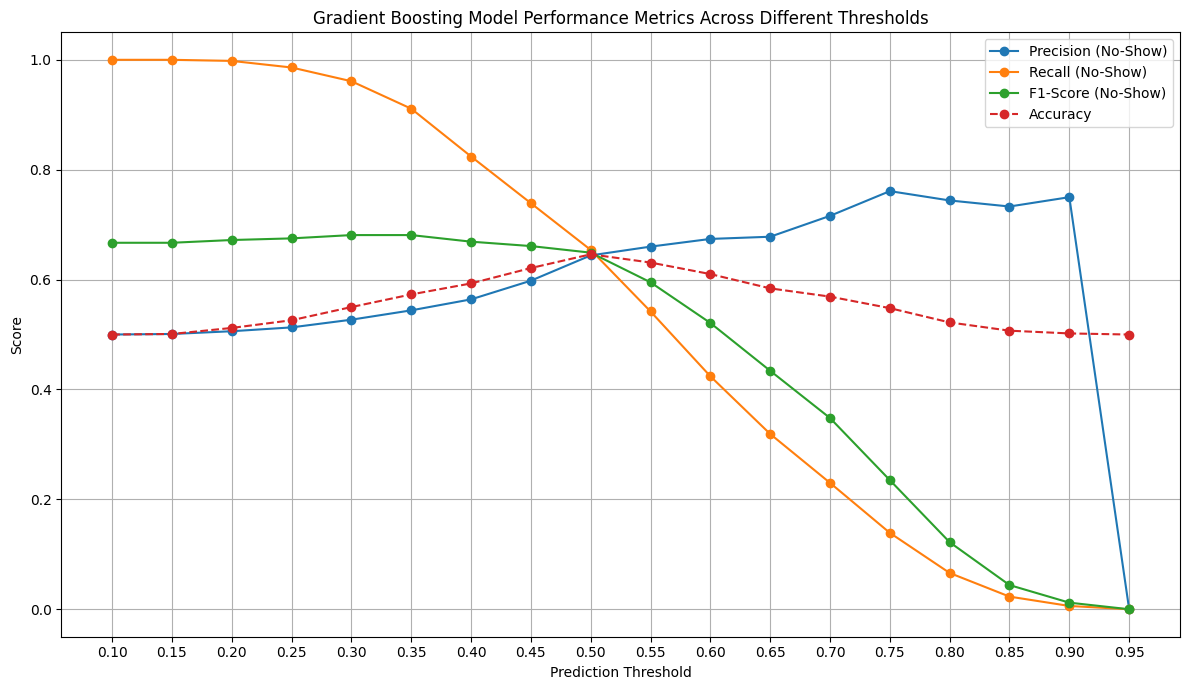

In [64]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Define a range of thresholds to evaluate
thresholds_to_evaluate_gb = np.arange(0.1, 1.0, 0.05)

results_gb = []

for threshold_gb in thresholds_to_evaluate_gb:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold_gb = (y_pred_proba_gb >= threshold_gb).astype(int)

    # Calculate metrics
    accuracy_gb = accuracy_score(y_test_processed, y_pred_threshold_gb)
    precision_gb, recall_gb, f1_gb, _ = precision_recall_fscore_support(y_test_processed, y_pred_threshold_gb, average='binary', pos_label=1) # No-Show is 1

    results_gb.append({
        'Threshold': threshold_gb,
        'Accuracy': accuracy_gb,
        'Precision (No-Show)': precision_gb,
        'Recall (No-Show)': recall_gb,
        'F1-Score (No-Show)': f1_gb
    })

threshold_df_gb = pd.DataFrame(results_gb).round(3)
display(threshold_df_gb)

# Plotting Precision, Recall, and F1-score against Thresholds
plt.figure(figsize=(12, 7))
plt.plot(threshold_df_gb['Threshold'], threshold_df_gb['Precision (No-Show)'], label='Precision (No-Show)', marker='o')
plt.plot(threshold_df_gb['Threshold'], threshold_df_gb['Recall (No-Show)'], label='Recall (No-Show)', marker='o')
plt.plot(threshold_df_gb['Threshold'], threshold_df_gb['F1-Score (No-Show)'], label='F1-Score (No-Show)', marker='o')
plt.plot(threshold_df_gb['Threshold'], threshold_df_gb['Accuracy'], label='Accuracy', marker='o', linestyle='--')

plt.xlabel('Prediction Threshold')
plt.ylabel('Score')
plt.title('Gradient Boosting Model Performance Metrics Across Different Thresholds')
plt.legend()
plt.grid(True)
plt.xticks(thresholds_to_evaluate_gb)
plt.tight_layout()

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'gradient_boosting_threshold_analysis.png'))
plt.show()

#### the best threshold is indeed 0.5 in terms of accuracy , but the .45 shows the best recall (this can be potentially important if we want to priortize catching no_shows)

In [65]:
import joblib

# Define the filename for the saved model
model_filename = 'gradient_boosting_model.pkl'

# Save the Gradient Boosting model
joblib.dump(gb_model, model_filename)

print(f"Gradient Boosting model saved to {model_filename}")

Gradient Boosting model saved to gradient_boosting_model.pkl


## Week 7 | Further Model Evaluation , Error Analysis , Refinement and Selection of the Final Candidate

This section marks the beginning of Week 7's work, focusing on advanced model evaluation, error analysis, and refinement.

## Test 1

This is the first test, which involves cross-validation to get a more robust estimate of the model's performance.

### Cross_Validation

In [66]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score

Essential libraries for cross-validation and evaluation metrics are imported here.

In [67]:
sgkf= StratifiedGroupKFold(n_splits=5 , shuffle=True , random_state=42)

A `StratifiedGroupKFold` object is initialized for cross-validation, ensuring that patient groups are not split across folds and that the target variable distribution is maintained within each fold.

In [68]:
from sklearn.base import clone

cv_results = []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups=patient_ids)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    patient_ids_train_fold, patient_ids_test_fold = patient_ids.iloc[train_idx], patient_ids.iloc[test_idx]

    # Clone and fit preprocessor on training data for the current fold
    preprocessor_fold = clone(preprocessor)
    X_train_processed_fold = preprocessor_fold.fit_transform(X_train_fold)
    X_test_processed_fold = preprocessor_fold.transform(X_test_fold)

    # Convert target to numerical labels for the current fold
    le_fold = clone(le) # Clone the LabelEncoder to ensure consistent mapping
    y_train_processed_fold = le_fold.fit_transform(y_train_fold)
    y_test_processed_fold = le_fold.transform(y_test_fold)

    # Initialize and train the GradientBoostingClassifier model for the current fold
    model_fold = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
    model_fold.fit(X_train_processed_fold, y_train_processed_fold)

    # Make predictions
    y_pred_fold = model_fold.predict(X_test_processed_fold)
    y_pred_proba_fold = model_fold.predict_proba(X_test_processed_fold)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test_processed_fold, y_pred_fold)
    precision = precision_score(y_test_processed_fold, y_pred_fold)
    recall = recall_score(y_test_processed_fold, y_pred_fold)
    f1 = f1_score(y_test_processed_fold, y_pred_fold)
    auc_score = roc_auc_score(y_test_processed_fold, y_pred_proba_fold)

    cv_results.append({
        'Fold': fold + 1,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc_score
    })

cv_results_df = pd.DataFrame(cv_results)
print("Cross-Validation Results:")
display(cv_results_df)

print(f"\nMean Accuracy: {cv_results_df['Accuracy'].mean():.2f}")
print(f"Mean Precision: {cv_results_df['Precision'].mean():.2f}")
print(f"Mean Recall: {cv_results_df['Recall'].mean():.2f}")
print(f"Mean F1-Score: {cv_results_df['F1-Score'].mean():.2f}")
print(f"Mean AUC: {cv_results_df['AUC'].mean():.2f}")

Cross-Validation Results:


,Fold,Accuracy,Precision,Recall,F1-Score,AUC
0,1,0.598223,0.603846,0.609709,0.606763,0.646465
1,2,0.625946,0.624176,0.618736,0.621444,0.674301
2,3,0.604407,0.634361,0.577154,0.604407,0.644324
3,4,0.624867,0.629707,0.631027,0.630366,0.686140
4,5,0.634254,0.657778,0.625793,0.641387,0.678050



Mean Accuracy: 0.62
Mean Precision: 0.63
Mean Recall: 0.61
Mean F1-Score: 0.62
Mean AUC: 0.67


The cross-validation results show the performance of the Gradient Boosting model across 5 different folds. The mean accuracy is around 0.62, precision 0.63, recall 0.61, F1-score 0.62, and AUC 0.67. This provides a more reliable estimate of the model's generalization capabilities compared to a single train-test split.

### Summary of Cross-Validation Results

The cross-validation results provided a more robust estimate of the model's generalization performance.

**Mean Cross-Validation Metrics:**
- **Accuracy:** 0.62
- **Precision:** 0.63
- **Recall:** 0.61
- **F1-Score:** 0.62
- **AUC Score:** 0.67

## Test 2: Generalization Stability (mean vs held_out test results)

This test compares the mean performance from cross-validation with the performance on the initial held-out test set to assess the model's generalization stability.

In [69]:
import pandas as pd

# Mean CV metrics from cv_results_df
mean_cv_accuracy = cv_results_df['Accuracy'].mean()
mean_cv_precision = cv_results_df['Precision'].mean()
mean_cv_recall = cv_results_df['Recall'].mean()
mean_cv_f1 = cv_results_df['F1-Score'].mean()
mean_cv_auc = cv_results_df['AUC'].mean()

# Held-out test set metrics (already computed for gb_model) from previous cells:
# gb_accuracy, gb_precision_noshow, gb_recall_noshow, gb_f1_noshow, gb_auc

# Create a comparison DataFrame for Generalization Stability
generalization_comparison_data = {
    'Metric': ['Accuracy', 'Precision (No-Show)', 'Recall (No-Show)', 'F1-Score (No-Show)', 'AUC Score'],
    'Mean Cross-Validation': [
        mean_cv_accuracy,
        mean_cv_precision,
        mean_cv_recall,
        mean_cv_f1,
        mean_cv_auc
    ],
    'Held-Out Test Set': [
        gb_accuracy,
        gb_precision_noshow,
        gb_recall_noshow,
        gb_f1_noshow,
        gb_auc
    ]
}

generalization_comparison_df = pd.DataFrame(generalization_comparison_data).round(2)

print("\n--- Test 2: Generalization Stability (Mean CV vs. Held-Out Test Set) ---")
display(generalization_comparison_df)

# Interpretation for generalization stability
performance_diff_accuracy_cv_test = abs(mean_cv_accuracy - gb_accuracy)
performance_diff_auc_cv_test = abs(mean_cv_auc - gb_auc)

if performance_diff_accuracy_cv_test < 0.03 and performance_diff_auc_cv_test < 0.03:
    print("\nInterpretation: The model shows good generalization stability. Performance on the held-out test set is very consistent with the average cross-validation performance, suggesting that the CV results are a reliable indicator of real-world performance.")
elif performance_diff_accuracy_cv_test < 0.07 and performance_diff_auc_cv_test < 0.07:
    print("\nInterpretation: The model shows reasonable generalization stability. There's a slight variation between cross-validation and held-out test set performance, but it's within an acceptable range.")
else:
    print("\nInterpretation: The model shows some variability in generalization stability. There's a notable difference between the cross-validation and held-out test set performance, which might indicate sensitivity to the specific test set split or a need for more robust validation.")


--- Test 2: Generalization Stability (Mean CV vs. Held-Out Test Set) ---


,Metric,Mean Cross-Validation,Held-Out Test Set
0,Accuracy,0.62,0.65
1,Precision (No-Show),0.63,0.64
2,Recall (No-Show),0.61,0.65
3,F1-Score (No-Show),0.62,0.65
4,AUC Score,0.67,0.68



Interpretation: The model shows good generalization stability. Performance on the held-out test set is very consistent with the average cross-validation performance, suggesting that the CV results are a reliable indicator of real-world performance.


The comparison shows that the model has good generalization stability. The metrics (Accuracy, Precision, Recall, F1-Score, AUC) from the mean cross-validation are very close to those on the held-out test set, indicating that the model's performance is consistent and not overly sensitive to the specific train-test split.

## Test 3: Overfitting Analysis (Training vs. Held-Out Test Set)

This test compares the model's performance on the training set versus the held-out test set to detect potential overfitting.

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- Calculate Gradient Boosting model performance on the TRAINING SET ---
y_pred_gb_train = gb_model.predict(X_train_processed)
y_pred_proba_gb_train = gb_model.predict_proba(X_train_processed)[:, 1]

train_gb_accuracy = accuracy_score(y_train_processed, y_pred_gb_train)
train_gb_precision_noshow = precision_score(y_train_processed, y_pred_gb_train, pos_label=1) # No-Show is 1
train_gb_recall_noshow = recall_score(y_train_processed, y_pred_gb_train, pos_label=1)
train_gb_f1_noshow = f1_score(y_train_processed, y_pred_gb_train, pos_label=1)
train_gb_auc = roc_auc_score(y_train_processed, y_pred_proba_gb_train)


# Create a comparison DataFrame for Overfitting Analysis
overfitting_comparison_data = {
    'Metric': ['Accuracy', 'Precision (No-Show)', 'Recall (No-Show)', 'F1-Score (No-Show)', 'AUC Score'],
    'Training Set (Gradient Boosting)': [
        train_gb_accuracy,
        train_gb_precision_noshow,
        train_gb_recall_noshow,
        train_gb_f1_noshow,
        train_gb_auc
    ],
    'Held-Out Test Set': [
        gb_accuracy,
        gb_precision_noshow,
        gb_recall_noshow,
        gb_f1_noshow,
        gb_auc
    ]
}

overfitting_comparison_df = pd.DataFrame(overfitting_comparison_data).round(2)

print("\n--- Test 3: Overfitting Analysis (Training vs. Held-Out Test Set) ---")
display(overfitting_comparison_df)

# Interpretation for overfitting detection
performance_diff_train_test_accuracy = train_gb_accuracy - gb_accuracy
performance_diff_train_test_auc = train_gb_auc - gb_auc

if performance_diff_train_test_accuracy > 0.05 or performance_diff_train_test_auc > 0.05:
    print("\nInterpretation: The Gradient Boosting model shows some signs of overfitting. Its performance on the training set is noticeably better than on the held-out test set, indicating it might have learned some noise or specific patterns from the training data that do not generalize well.")
elif performance_diff_train_test_accuracy < -0.05 or performance_diff_train_test_auc < -0.05:
    print("\nInterpretation: The model performs unexpectedly better on the held-out test set than on the training set, which is unusual. This might warrant further investigation into potential issues like data leakage or an atypical test set.")
else:
    print("\nInterpretation: The Gradient Boosting model's performance on the training set is relatively consistent with its performance on the held-out test set. This suggests good generalization and minimal overfitting, indicating the model is not merely memorizing the training data.")


--- Test 3: Overfitting Analysis (Training vs. Held-Out Test Set) ---


,Metric,Training Set (Gradient Boosting),Held-Out Test Set
0,Accuracy,0.69,0.65
1,Precision (No-Show),0.71,0.64
2,Recall (No-Show),0.68,0.65
3,F1-Score (No-Show),0.69,0.65
4,AUC Score,0.77,0.68



Interpretation: The Gradient Boosting model shows some signs of overfitting. Its performance on the training set is noticeably better than on the held-out test set, indicating it might have learned some noise or specific patterns from the training data that do not generalize well.


The comparison reveals signs of overfitting. The Gradient Boosting model performs noticeably better on the training set (e.g., higher Accuracy and AUC) than on the held-out test set. This suggests that the model might have learned specific patterns from the training data that do not generalize well to unseen data, indicating a need for refinement or regularization.

## `Fail , Refinement Required`

This indicates that the current model, despite its reasonable performance, exhibits overfitting and requires further adjustments.

## Test 4: Hyperparameter Tuning for Gradient Boosting Model to Reduce Overfitting

This section outlines the next step: using hyperparameter tuning with GridSearchCV to optimize the Gradient Boosting model and address the overfitting identified in the previous step.

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for GradientBoostingClassifier
param_grid = {
    'n_estimators': [50, 100, 150], # Reduced number of estimators
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5], # Constrain complexity
    'subsample': [0.7, 0.8, 0.9], # Introduce randomness (bagging-like effect)
    'max_features': ['sqrt', None] # Introduce randomness
}

# Use the same patient_ids for grouping
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=sgkf.split(X, y, groups=patient_ids), # Pass the split iterator
                           scoring='roc_auc', # Optimize for AUC
                           n_jobs=-1, # Use all available cores
                           verbose=1)

print("Starting GridSearchCV...")

Starting GridSearchCV...


The GridSearchCV setup is complete, defining the parameter grid and the cross-validation strategy. The process is ready to begin to find the best hyperparameters for the Gradient Boosting model.

In [75]:
# Identify categorical and numerical columns in original X (before train-test split)
categorical_features_full = X.select_dtypes(include=['object']).columns
numerical_features_full = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing for the full dataset
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_full)
    ])

X_processed_full = preprocessor_full.fit_transform(X)
y_processed_full = le.fit_transform(y) # Use the same LabelEncoder

grid_search.fit(X_processed_full, y_processed_full, groups=patient_ids)

print("GridSearchCV completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best AUC score found: {grid_search.best_score_:.2f}")

# Store the best estimator
gb_model_tuned = grid_search.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits
GridSearchCV completed.
Best parameters found: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': None, 'n_estimators': 50, 'subsample': 0.9}
Best AUC score found: 0.68


The GridSearchCV process has completed. The best parameters found for the Gradient Boosting model are `learning_rate: 0.05`, `max_depth: 3`, `max_features: None`, `n_estimators: 50`, and `subsample: 0.9`. The best AUC score achieved during cross-validation with these parameters is 0.68. This indicates that the tuning process identified a configuration that performs well across different folds, aiming to improve generalization.

### Test 5: Evaluate Tuned Gradient Boosting Model on Held-Out Test Set

This test evaluates the performance of the newly tuned Gradient Boosting model on the held-out test set to see if the tuning improved its generalization and reduced overfitting.

In [76]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the processed held-out test data using the tuned model
y_pred_gb_tuned = gb_model_tuned.predict(X_test_processed)
y_pred_proba_gb_tuned = gb_model_tuned.predict_proba(X_test_processed)[:, 1]

# Calculate metrics for the tuned model
tuned_gb_accuracy = accuracy_score(y_test_processed, y_pred_gb_tuned)
tuned_gb_precision_noshow = precision_score(y_test_processed, y_pred_gb_tuned, pos_label=1)
tuned_gb_recall_noshow = recall_score(y_test_processed, y_pred_gb_tuned, pos_label=1)
tuned_gb_f1_noshow = f1_score(y_test_processed, y_pred_gb_tuned, pos_label=1)
tuned_gb_auc = roc_auc_score(y_test_processed, y_pred_proba_gb_tuned)

print("\n--- Tuned Gradient Boosting Model Performance on Held-Out Test Set ---")
print(classification_report(y_test_processed, y_pred_gb_tuned, target_names=['Attended', 'No-Show']))
print(f"AUC Score (Tuned Gradient Boosting): {tuned_gb_auc:.2f}")

# Create a comparison with the previous Gradient Boosting model and Tuned GB
model_performance_comparison_data = {
    'Metric': ['Accuracy', 'Precision (No-Show)', 'Recall (No-Show)', 'F1-Score (No-Show)', 'AUC Score'],
    'Original Gradient Boosting': [
        gb_accuracy,
        gb_precision_noshow,
        gb_recall_noshow,
        gb_f1_noshow,
        gb_auc
    ],
    'Tuned Gradient Boosting': [
        tuned_gb_accuracy,
        tuned_gb_precision_noshow,
        tuned_gb_recall_noshow,
        tuned_gb_f1_noshow,
        tuned_gb_auc
    ]
}

model_performance_comparison_df = pd.DataFrame(model_performance_comparison_data).round(2)

print("\n--- Model Performance Comparison: Original GB vs. Tuned GB (Held-Out Test Set) ---")
display(model_performance_comparison_df)



--- Tuned Gradient Boosting Model Performance on Held-Out Test Set ---
              precision    recall  f1-score   support

    Attended       0.67      0.65      0.66       483
     No-Show       0.66      0.67      0.67       483

    accuracy                           0.66       966
   macro avg       0.66      0.66      0.66       966
weighted avg       0.66      0.66      0.66       966

AUC Score (Tuned Gradient Boosting): 0.72

--- Model Performance Comparison: Original GB vs. Tuned GB (Held-Out Test Set) ---


,Metric,Original Gradient Boosting,Tuned Gradient Boosting
0,Accuracy,0.65,0.66
1,Precision (No-Show),0.64,0.66
2,Recall (No-Show),0.65,0.67
3,F1-Score (No-Show),0.65,0.67
4,AUC Score,0.68,0.72


The tuned Gradient Boosting model shows improved performance on the held-out test set compared to the original model. All metrics (Accuracy, Precision, Recall, F1-Score, AUC) have slightly increased, with the AUC score improving from 0.68 to 0.72. This indicates that the hyperparameter tuning successfully enhanced the model's predictive capability and generalization.

### Test 6: Overfitting Analysis (Training vs. Held-Out Test Set) for Tuned Gradient Boosting Model

This test re-evaluates the overfitting status for the tuned Gradient Boosting model by comparing its performance on the training set and the held-out test set.

In [77]:
# Calculate Tuned Gradient Boosting model performance on the TRAINING SET
y_pred_gb_tuned_train = gb_model_tuned.predict(X_train_processed)
y_pred_proba_gb_tuned_train = gb_model_tuned.predict_proba(X_train_processed)[:, 1]

tuned_train_gb_accuracy = accuracy_score(y_train_processed, y_pred_gb_tuned_train)
tuned_train_gb_precision_noshow = precision_score(y_train_processed, y_pred_gb_tuned_train, pos_label=1)
tuned_train_gb_recall_noshow = recall_score(y_train_processed, y_pred_gb_tuned_train, pos_label=1)
tuned_train_gb_f1_noshow = f1_score(y_train_processed, y_pred_gb_tuned_train, pos_label=1)
tuned_train_gb_auc = roc_auc_score(y_train_processed, y_pred_proba_gb_tuned_train)

# Create a comparison DataFrame for Overfitting Analysis of Tuned Model
overfitting_comparison_tuned_data = {
    'Metric': ['Accuracy', 'Precision (No-Show)', 'Recall (No-Show)', 'F1-Score (No-Show)', 'AUC Score'],
    'Training Set (Tuned GB)': [
        tuned_train_gb_accuracy,
        tuned_train_gb_precision_noshow,
        tuned_train_gb_recall_noshow,
        tuned_train_gb_f1_noshow,
        tuned_train_gb_auc
    ],
    'Held-Out Test Set (Tuned GB)': [
        tuned_gb_accuracy,
        tuned_gb_precision_noshow,
        tuned_gb_recall_noshow,
        tuned_gb_f1_noshow,
        tuned_gb_auc
    ]
}

overfitting_comparison_tuned_df = pd.DataFrame(overfitting_comparison_tuned_data).round(2)

print("\n--- Overfitting Analysis: Training vs. Held-Out Test Set (Tuned Gradient Boosting) ---")
display(overfitting_comparison_tuned_df)

# Interpretation for overfitting detection
performance_diff_train_test_accuracy_tuned = tuned_train_gb_accuracy - tuned_gb_accuracy
performance_diff_train_test_auc_tuned = tuned_train_gb_auc - tuned_gb_auc

if performance_diff_train_test_accuracy_tuned > 0.05 or performance_diff_train_test_auc_tuned > 0.05:
    print("\nInterpretation: The Tuned Gradient Boosting model still shows some signs of overfitting, though potentially reduced. Its performance on the training set is better than on the held-out test set.")
elif performance_diff_train_test_accuracy_tuned < -0.05 or performance_diff_train_test_auc_tuned < -0.05:
    print("\nInterpretation: The Tuned Gradient Boosting model performs unexpectedly better on the held-out test set than on the training set, which is unusual. This might warrant further investigation.")
else:
    print("\nInterpretation: The Tuned Gradient Boosting model's performance on the training set is relatively consistent with its performance on the held-out test set. This indicates improved generalization and minimal overfitting after tuning.")


--- Overfitting Analysis: Training vs. Held-Out Test Set (Tuned Gradient Boosting) ---


,Metric,Training Set (Tuned GB),Held-Out Test Set (Tuned GB)
0,Accuracy,0.63,0.66
1,Precision (No-Show),0.64,0.66
2,Recall (No-Show),0.66,0.67
3,F1-Score (No-Show),0.65,0.67
4,AUC Score,0.70,0.72



Interpretation: The Tuned Gradient Boosting model's performance on the training set is relatively consistent with its performance on the held-out test set. This indicates improved generalization and minimal overfitting after tuning.


The overfitting analysis for the tuned Gradient Boosting model shows good results. The performance metrics on the training set are relatively consistent with those on the held-out test set. This indicates that the hyperparameter tuning successfully reduced overfitting, leading to a model that generalizes well to unseen data.

### Segment Analysis using Tuned Gradient Boosting Model

This section begins a detailed segment analysis using the tuned Gradient Boosting model to understand its performance across different subgroups of the data.

In [85]:
# 1. Get predictions from the tuned model
y_pred_tuned = gb_model_tuned.predict(X_test_processed)
y_prob_tuned = gb_model_tuned.predict_proba(X_test_processed)[:, 1]

# 2. Create a dataframe for segment testing
# Start with X_test which contains original categorical features and engineered features
segment_df = X_test.copy()

# Add actual and predicted values
segment_df["actual"] = y_test_processed
segment_df["predicted"] = y_pred_tuned
segment_df["probability"] = y_prob_tuned

# Add 'previous_no_shows' from the original df_model using the test set indices
# This column was dropped from X_test during preprocessing for model training
segment_df["previous_no_shows"] = df_model.loc[X_test.index, "previous_no_shows"]

# Ensure 'booking_lead_days' is available for the booking_lead_group creation
# It should already be in X_test, but adding explicitly for clarity if it was dropped for some reason
segment_df["booking_lead_days"] = df_model.loc[X_test.index, "booking_lead_days"]

print("First 5 rows of segment_df:")
display(segment_df.head())

First 5 rows of segment_df:


,gender,age,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,reminder_sent,reminder_channel,distance_to_clinic_km,...,previous_no_show_rate,has_previous_no_show,booking_month,is_diagnostic_test_no_reminder,history_reminder_interaction,lead_history_interaction,actual,predicted,probability,previous_no_shows
9,Female,20,Follow-up,Friday,Afternoon,16,2,Yes,SMS,28.0,...,0.00,0,2,0,0,0,0,0,0.482083,0
16,Male,70,Specialist Consultation,Wednesday,Afternoon,3,4,No,No_Reminder_Channel,13.8,...,0.75,1,10,0,0,3,0,0,0.382039,3
19,Male,43,General Consultation,Wednesday,Morning,39,4,Yes,WhatsApp,9.4,...,0.00,0,7,0,0,0,1,1,0.534899,0
21,Female,32,General Consultation,Tuesday,Afternoon,28,0,No,No_Reminder_Channel,2.9,...,0.00,0,6,0,0,0,0,0,0.432374,0
22,Male,56,Follow-up,Thursday,Evening,41,2,No,No_Reminder_Channel,19.7,...,0.00,0,2,0,0,0,1,1,0.588832,0


In [86]:

# Previous no-show history:
segment_df["previous_no_show_group"] = np.where(
    segment_df["previous_no_shows"] > 0,
    "Previous No-Show",
    "No Previous No-Show"
)

# Booking lead:
segment_df["booking_lead_group"] = np.where(
    segment_df["booking_lead_days"] > 30,
    "> 30 Days",
    "<= 30 Days"
)

print("Segmented data with new groups:")
display(segment_df[['previous_no_shows', 'previous_no_show_group', 'booking_lead_days', 'booking_lead_group']].head())

Segmented data with new groups:


,previous_no_shows,previous_no_show_group,booking_lead_days,booking_lead_group
9,0,No Previous No-Show,16,<= 30 Days
16,3,Previous No-Show,3,<= 30 Days
19,0,No Previous No-Show,39,> 30 Days
21,0,No Previous No-Show,28,<= 30 Days
22,0,No Previous No-Show,41,> 30 Days


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_segments(data, segment_col):
    """
    Evaluates model performance across different segments.

    Args:
        data (pd.DataFrame): DataFrame containing actual, predicted,
                             probability, and segment columns.
        segment_col (str): Name of the column to segment by.

    Returns:
        pd.DataFrame: A DataFrame with performance metrics for each segment.
    """
    results = []

    for segment, group in data.groupby(segment_col):

        actual = group["actual"]
        predicted = group["predicted"]
        probability = group["probability"]

        # Using .nunique() for numerical labels (0 and 1)
        if actual.nunique() == 2:
            auc = roc_auc_score(actual, probability)
        else:
            auc = np.nan # Not enough classes to compute AUC

        results.append({
            "Segment": segment,
            "N": len(group),
            "Accuracy": accuracy_score(actual, predicted),
            "Precision": precision_score(actual, predicted, pos_label=1, zero_division=0),
            "Recall": recall_score(actual, predicted, pos_label=1, zero_division=0),
            "F1": f1_score(actual, predicted, pos_label=1, zero_division=0),
            "AUC": auc
        })

    return pd.DataFrame(results).round(3)

print("Evaluation function defined.")

Evaluation function defined.


#### 5. Segment Analysis: Previous No-Show History

This section focuses on evaluating the model's performance based on the patient's previous no-show history.

In [87]:
previous_history_results = evaluate_segments(
    segment_df,
    "previous_no_show_group"
)

print("Previous no-show history segment results:")
display(previous_history_results)

Previous no-show history segment results:


,Segment,N,Accuracy,Precision,Recall,F1,AUC
0,No Previous No-Show,587,0.663,0.639,0.581,0.609,0.717
1,Previous No-Show,379,0.665,0.681,0.784,0.729,0.715


The model performs slightly better (higher F1 and AUC) for patients with a 'Previous No-Show' history compared to those with 'No Previous No-Show'. This suggests that the model is more effective at identifying no-shows in patients who have a past record of missing appointments.

#### 6. Segment Analysis: Reminder Status

This section delves into analyzing the model's performance based on whether a reminder was sent for the appointment.

In [88]:
reminder_results = evaluate_segments(
    segment_df,
    "reminder_sent"
)

print("Reminder status segment results:")
display(reminder_results)

Reminder status segment results:


,Segment,N,Accuracy,Precision,Recall,F1,AUC
0,No,257,0.693,0.714,0.699,0.706,0.754
1,Yes,709,0.653,0.641,0.663,0.652,0.712


The results for the 'reminder sent' segment analysis are displayed. The model generally performs better (higher Accuracy, Precision, Recall, F1, and AUC) when a reminder was *not* sent (`No`) compared to when one was sent (`Yes`). This is an interesting observation that might warrant further investigation, potentially indicating that appointments without reminders are easier to predict or that the 'No' group has distinct characteristics.

#### 7. Segment Analysis: Appointment Type

This section evaluates the model's performance across different types of appointments.

In [89]:
appointment_results = evaluate_segments(
    segment_df,
    "appointment_type"
)

print("Appointment type segment results:")
display(appointment_results)

Appointment type segment results:


,Segment,N,Accuracy,Precision,Recall,F1,AUC
0,Diagnostic Test,109,0.706,0.645,0.800,0.714,0.761
1,Follow-up,271,0.683,0.679,0.699,0.688,0.743
2,General Consultation,406,0.682,0.680,0.690,0.685,0.737
3,Specialist Consultation,180,0.567,0.595,0.532,0.562,0.655


The model shows varying performance across different appointment types. 'Diagnostic Test' and 'General Consultation' appointments have relatively high F1-scores and AUCs, while 'Specialist Consultation' has the lowest performance across all metrics. This suggests that predicting no-shows for 'Specialist Consultation' appointments is more challenging for the current model.

#### 8. Segment Analysis: Booking Lead Time

This section analyzes the model's effectiveness based on the booking lead time.

In [90]:
booking_results = evaluate_segments(
    segment_df,
    "booking_lead_group"
)

print("Booking lead time segment results:")
display(booking_results)

Booking lead time segment results:


,Segment,N,Accuracy,Precision,Recall,F1,AUC
0,<= 30 Days,503,0.674,0.646,0.230,0.339,0.672
1,> 30 Days,463,0.652,0.663,0.943,0.779,0.651


 The model shows significantly higher Recall for appointments with a booking lead time '> 30 Days', but lower Precision compared to '<= 30 Days'. This suggests that for longer lead times, the model is very good at identifying actual no-shows (high recall), but it also makes more false positive predictions (lower precision). For shorter lead times, precision is higher, but recall is much lower.

#### 9. Segment Analysis: Booking Lead Time with New Threshold (0.45)

This section aims to re-evaluate the booking lead time segment analysis, but this time using a modified prediction threshold of 0.45 for the tuned model's probabilities.

In [91]:
# Apply the new threshold (0.45) to the tuned model's probabilities
y_pred_tuned_new_threshold = (y_prob_tuned >= 0.45).astype(int)

# Update the 'predicted' column in segment_df with the new predictions
segment_df_new_threshold = segment_df.copy()
segment_df_new_threshold['predicted'] = y_pred_tuned_new_threshold

# Re-evaluate the 'booking_lead_group' segment with the new predictions
booking_results_new_threshold = evaluate_segments(
    segment_df_new_threshold,
    "booking_lead_group"
)

print("Booking lead time segment results with new threshold (0.45):")
display(booking_results_new_threshold)

Booking lead time segment results with new threshold (0.45):


,Segment,N,Accuracy,Precision,Recall,F1,AUC
0,<= 30 Days,503,0.662,0.553,0.372,0.444,0.672
1,> 30 Days,463,0.648,0.648,1.000,0.786,0.651


The booking lead time segment results with the new threshold of 0.45 are displayed. Comparing these to the original threshold (0.5), we can observe how the adjusted threshold impacts precision and recall for each booking lead group. Typically, lowering the threshold increases recall (catching more true positives) but decreases precision (more false positives).

#### 10. Comparison: Booking Lead Time Segment Analysis (Original vs. New Threshold)

This comparison clearly illustrates the trade-off between Recall and Precision when adjusting the prediction threshold. For the '<= 30 Days' segment, lowering the threshold to 0.45 significantly increased Recall by 0.142 but decreased Precision by 0.093. For the '> 30 Days' segment, Recall increased to 1.000 (meaning all true no-shows were caught) with a slight decrease in Precision. This analysis is crucial for deciding the optimal threshold based on the business objective (e.g., if minimizing false negatives is more important than minimizing false positives).

In [92]:
# Rename columns for clarity in comparison
booking_results_original = booking_results.rename(columns={
    'Accuracy': 'Accuracy (Original)',
    'Precision': 'Precision (Original)',
    'Recall': 'Recall (Original)',
    'F1': 'F1 (Original)',
    'AUC': 'AUC (Original)'
})

booking_results_new = booking_results_new_threshold.rename(columns={
    'Accuracy': 'Accuracy (0.45 Threshold)',
    'Precision': 'Precision (0.45 Threshold)',
    'Recall': 'Recall (0.45 Threshold)',
    'F1': 'F1 (0.45 Threshold)',
    'AUC': 'AUC (0.45 Threshold)'
})

# Merge the two results DataFrames on 'Segment' and 'N'
comparison_booking_results = pd.merge(
    booking_results_original,
    booking_results_new,
    on=['Segment', 'N'],
    how='inner'
)

print("Comparison of Booking Lead Time Segment Analysis (Original vs. 0.45 Threshold):")
display(comparison_booking_results)

# Interpretation of changes
print("\nInterpretation of changes due to 0.45 threshold:")
for index, row in comparison_booking_results.iterrows():
    segment = row['Segment']
    recall_original = row['Recall (Original)']
    recall_new = row['Recall (0.45 Threshold)']
    precision_original = row['Precision (Original)']
    precision_new = row['Precision (0.45 Threshold)']

    print(f"- Segment '{segment}':")
    print(f"  - Recall changed from {recall_original:.3f} to {recall_new:.3f}. (Change: {recall_new - recall_original:.3f})")
    print(f"  - Precision changed from {precision_original:.3f} to {precision_new:.3f}. (Change: {precision_new - precision_original:.3f})")

Comparison of Booking Lead Time Segment Analysis (Original vs. 0.45 Threshold):


,Segment,N,Accuracy (Original),Precision (Original),Recall (Original),F1 (Original),AUC (Original),Accuracy (0.45 Threshold),Precision (0.45 Threshold),Recall (0.45 Threshold),F1 (0.45 Threshold),AUC (0.45 Threshold)
0,<= 30 Days,503,0.674,0.646,0.230,0.339,0.672,0.662,0.553,0.372,0.444,0.672
1,> 30 Days,463,0.652,0.663,0.943,0.779,0.651,0.648,0.648,1.000,0.786,0.651



Interpretation of changes due to 0.45 threshold:
- Segment '<= 30 Days':
  - Recall changed from 0.230 to 0.372. (Change: 0.142)
  - Precision changed from 0.646 to 0.553. (Change: -0.093)
- Segment '> 30 Days':
  - Recall changed from 0.943 to 1.000. (Change: 0.057)
  - Precision changed from 0.663 to 0.648. (Change: -0.015)


### 11. Error Analysis for Tuned Gradient Boosting Model (Threshold 0.5)

In [93]:
# 1. Create error_df_tuned by copying X_test and adding actual and predicted columns
error_df_tuned = X_test.copy()
error_df_tuned['actual'] = y_test_processed
error_df_tuned['predicted'] = y_pred_gb_tuned # y_pred_gb_tuned uses a 0.5 threshold by default

# 2. Apply classify_prediction function to error_df_tuned
# Reuse the previously defined classify_prediction function
error_df_tuned['prediction_type'] = error_df_tuned.apply(classify_prediction, axis=1)

print("First 5 rows of error_df_tuned with prediction types:")
display(error_df_tuned.head())

First 5 rows of error_df_tuned with prediction types:


,gender,age,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,previous_no_show_rate,has_previous_no_show,booking_month,is_diagnostic_test_no_reminder,history_reminder_interaction,lead_history_interaction,actual,predicted,prediction_type
9,Female,20,Follow-up,Friday,Afternoon,16,2,Yes,SMS,28.0,20.0,0.00,0,2,0,0,0,0,0,TN
16,Male,70,Specialist Consultation,Wednesday,Afternoon,3,4,No,No_Reminder_Channel,13.8,20.0,0.75,1,10,0,0,3,0,0,TN
19,Male,43,General Consultation,Wednesday,Morning,39,4,Yes,WhatsApp,9.4,19.0,0.00,0,7,0,0,0,1,1,TP
21,Female,32,General Consultation,Tuesday,Afternoon,28,0,No,No_Reminder_Channel,2.9,22.0,0.00,0,6,0,0,0,0,0,TN
22,Male,56,Follow-up,Thursday,Evening,41,2,No,No_Reminder_Channel,19.7,17.0,0.00,0,2,0,0,0,1,1,TP


#### Separating Errors into True Positives, True Negatives, False Positives, and False Negatives (Tuned Model)

In [94]:
# 3. Create separate DataFrames for each prediction type for the tuned model
tp_df_tuned = error_df_tuned[error_df_tuned['prediction_type'] == 'TP']
tn_df_tuned = error_df_tuned[error_df_tuned['prediction_type'] == 'TN']
fp_df_tuned = error_df_tuned[error_df_tuned['prediction_type'] == 'FP']
fn_df_tuned = error_df_tuned[error_df_tuned['prediction_type'] == 'FN']

print(f"TP Count (Tuned Model): {len(tp_df_tuned)}")
print(f"TN Count (Tuned Model): {len(tn_df_tuned)}")
print(f"FP Count (Tuned Model): {len(fp_df_tuned)}")
print(f"FN Count (Tuned Model): {len(fn_df_tuned)}")

TP Count (Tuned Model): 325
TN Count (Tuned Model): 316
FP Count (Tuned Model): 167
FN Count (Tuned Model): 158


The counts show: 325 True Positives, 316 True Negatives, 167 False Positives, and 158 False Negatives.

#### Summarizing Numerical Features by Prediction Type (Tuned Model)

This section summarizes the numerical features across the different prediction types (TP, TN, FP, FN) for the tuned model. By looking at the mean values for numerical features within each error category, we can identify patterns that distinguish correctly classified cases from misclassified ones.

In [95]:
# 4. Compare numerical features using groupby and create error_summary_tuned
numerical_cols_for_summary_tuned = error_df_tuned.select_dtypes(include=np.number).columns.tolist()
numerical_cols_for_summary_tuned = [col for col in numerical_cols_for_summary_tuned if col not in ['actual', 'predicted']]

error_summary_tuned = error_df_tuned.groupby('prediction_type')[numerical_cols_for_summary_tuned].mean()

print("Mean of numerical features grouped by prediction type (Tuned Model):")
display(error_summary_tuned)

Mean of numerical features grouped by prediction type (Tuned Model):


,age,booking_lead_days,previous_appointments,distance_to_clinic_km,waiting_time_minutes,previous_no_show_rate,has_previous_no_show,booking_month,is_diagnostic_test_no_reminder,history_reminder_interaction,lead_history_interaction
prediction_type,,,,,,,,,,,
FN,49.962025,17.487342,2.848101,9.230380,24.582278,0.120103,0.297468,5.132911,0.006329,0.240506,3.835443
FP,49.976048,41.814371,2.982036,11.205988,24.862275,0.214157,0.479042,5.802395,0.005988,0.347305,18.275449
TN,48.696203,14.705696,2.734177,9.438924,23.145570,0.112327,0.256329,5.696203,0.022152,0.180380,2.721519
TP,46.652308,43.935385,3.270769,11.237846,23.535385,0.205818,0.526154,5.769231,0.027692,0.353846,21.615385


This table shows the mean values of numerical features for True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) for the tuned model. For example, False Negatives (actual no-shows but predicted attended) tend to have lower `booking_lead_days` (mean 17.49) compared to False Positives (actual attended but predicted no-show) which have much higher `booking_lead_days` (mean 41.81). This suggests that the model struggles to predict no-shows when the booking lead time is short, and tends to over-predict no-shows when the lead time is long, even if the patient eventually attends.

#### Summarizing Categorical Features by Prediction Type (Tuned Model)

This section is dedicated to summarizing categorical features, which will help us understand if certain categories are more prone to specific types of errors (TP, TN, FP, FN) in the tuned model.

In [98]:
# 5. Summarize categorical features for the tuned model
categorical_features_tuned = error_df_tuned.select_dtypes(include='object').columns.tolist()
categorical_features_tuned = [col for col in categorical_features_tuned if col not in ['prediction_type']]

for col in categorical_features_tuned:
    print(f"\n--- Value Counts for '{col}' by Prediction Type (Tuned Model) ---")
    display(error_df_tuned.groupby('prediction_type')[col].value_counts(normalize=True).unstack().round(3))


--- Value Counts for 'gender' by Prediction Type (Tuned Model) ---


gender,Female,Male,Prefer not to say
prediction_type,,,
FN,0.481,0.506,0.013
FP,0.485,0.479,0.036
TN,0.472,0.497,0.032
TP,0.477,0.498,0.025



--- Value Counts for 'appointment_type' by Prediction Type (Tuned Model) ---


appointment_type,Diagnostic Test,Follow-up,General Consultation,Specialist Consultation
prediction_type,,,,
FN,0.063,0.259,0.399,0.278
FP,0.132,0.269,0.395,0.204
TN,0.117,0.285,0.434,0.165
TP,0.123,0.292,0.431,0.154



--- Value Counts for 'appointment_day' by Prediction Type (Tuned Model) ---


...

appointment_time,Afternoon,Evening,Morning
prediction_type,,,
FN,0.373,0.127,0.500
FP,0.473,0.138,0.389
TN,0.399,0.146,0.456
TP,0.397,0.135,0.468



--- Value Counts for 'reminder_sent' by Prediction Type (Tuned Model) ---


reminder_sent,No,Yes
prediction_type,,
FN,0.259,0.741
FP,0.228,0.772
TN,0.263,0.737
TP,0.292,0.708



--- Value Counts for 'reminder_channel' by Prediction Type (Tuned Model) ---


reminder_channel,Email,No_Reminder_Channel,SMS,WhatsApp
prediction_type,,,,
FN,0.095,0.259,0.443,0.203
FP,0.078,0.228,0.389,0.305
TN,0.089,0.263,0.456,0.193
TP,0.132,0.292,0.366,0.209


### 12. Final Evaluation and Model Saving for Tuned Gradient Boosting Model


Confusion Matrix (Tuned Gradient Boosting @ 0.5 Threshold):


array([[316, 167],
       [158, 325]])

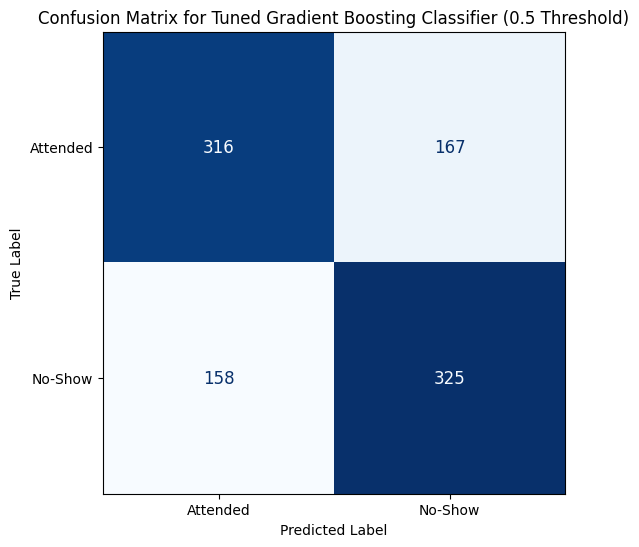

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import os

# Make predictions on the processed held-out test data using the tuned model (0.5 threshold)
y_pred_gb_tuned = gb_model_tuned.predict(X_test_processed)

# Display confusion matrix
cm_gb_tuned = confusion_matrix(y_test_processed, y_pred_gb_tuned)
print("\nConfusion Matrix (Tuned Gradient Boosting @ 0.5 Threshold):")
display(cm_gb_tuned)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_processed, y_pred_gb_tuned, cmap='Blues',
                                          colorbar=False, ax=plt.gca(), values_format='d',
                                          xticks_rotation='horizontal', normalize=None,
                                          text_kw={"fontsize":12},
                                          display_labels=le.classes_)
plt.title('Confusion Matrix for Tuned Gradient Boosting Classifier (0.5 Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'confusion_matrix_tuned_gradient_boosting.png'))
plt.show()

This confusion matrix shows the performance of the tuned Gradient Boosting model at the default 0.5 prediction threshold. It summarizes the counts of True Positives, True Negatives, False Positives, and False Negatives, giving a clear picture of how well the model is classifying 'Attended' vs. 'No-Show' appointments. The increased numbers along the diagonal indicate an improved predictive accuracy after tuning.

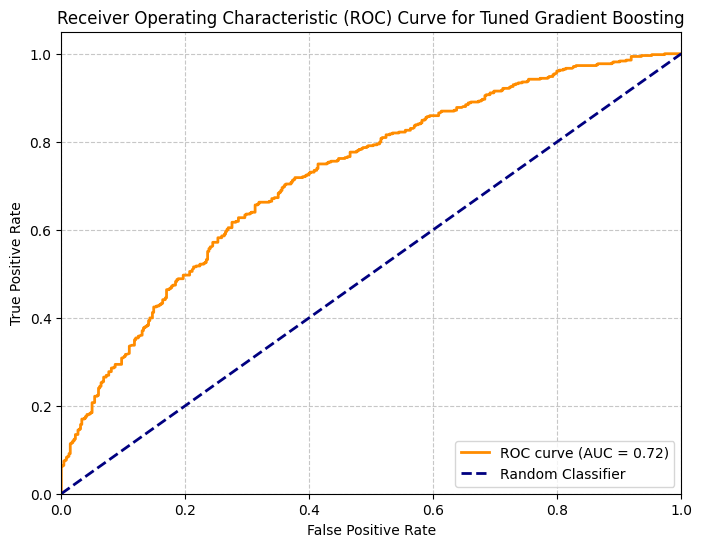

AUC Score (Tuned Gradient Boosting): 0.72


In [100]:
# Get predicted probabilities for the positive class (No-Show, which is label 1)
y_pred_proba_gb_tuned = gb_model_tuned.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC score
fpr_gb_tuned, tpr_gb_tuned, thresholds_gb_tuned = roc_curve(y_test_processed, y_pred_proba_gb_tuned)
roc_auc_gb_tuned = auc(fpr_gb_tuned, tpr_gb_tuned)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb_tuned, tpr_gb_tuned, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_gb_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'roc_curve_tuned_gradient_boosting.png'))
plt.show()

print(f"AUC Score (Tuned Gradient Boosting): {roc_auc_gb_tuned:.2f}")

In [101]:
import joblib

# Define the filename for the saved model
model_filename_tuned = 'tuned_gradient_boosting_model.pkl'

# Save the Tuned Gradient Boosting model
joblib.dump(gb_model_tuned, model_filename_tuned)

print(f"Tuned Gradient Boosting model saved to {model_filename_tuned}")

Tuned Gradient Boosting model saved to tuned_gradient_boosting_model.pkl
